# Helper funcs

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict

def ddw_group_rep(connectomes, dist_mat, hemi, n_bins=22, rng=None):
    """
    Construye un conectoma representativo (DDW) de un grupo de sujetos.
    Mantiene la densidad intra/inter-hemisférica por bins de distancia.
    Asigna pesos mediante muestreo aleatorio de la cohorte empírica.
    """
    if rng is None: 
        rng = np.random.default_rng(42)
        
    N_subs = len(connectomes)
    N_nodes = connectomes[0].shape[0]
    
    # 1. Extraer estadísticas empíricas (Frecuencia, Peso medio, Pool de pesos)
    freq = np.zeros((N_nodes, N_nodes))
    avg_w = np.zeros((N_nodes, N_nodes))
    weights_pool = { (i,j): [] for i in range(N_nodes) for j in range(i+1, N_nodes) }
    
    for adj in connectomes:
        A = np.triu(adj, 1) # Asegurar red no dirigida
        freq += (A > 0).astype(int)
        avg_w += A
        
        rows, cols = A.nonzero()
        for r, c in zip(rows, cols):
            weights_pool[(r,c)].append(A[r,c])
            
    avg_w = np.divide(avg_w, freq, out=np.zeros_like(avg_w), where=freq!=0)
    group_rep = np.zeros((N_nodes, N_nodes))
    
    # 2. Procesar enlaces separando intra e inter-hemisféricos
    for is_intra in [True, False]:
        mask_hemi = (hemi == 1) if is_intra else (hemi == 0)
        mask_valid = np.triu(mask_hemi, 1) & (freq > 0)
        
        if not np.any(mask_valid): continue
            
        valid_edges = np.argwhere(mask_valid)
        distances = dist_mat[valid_edges[:,0], valid_edges[:,1]]
        
        # Bins equitativos basados en percentiles de distancia
        bins = np.percentile(distances, np.linspace(0, 100, n_bins+1))
        bins[-1] += 1e-5 
        edge_bin_idx = np.digitize(distances, bins) - 1
        
        # 3. Consenso topológico por bin
        for b in range(n_bins):
            idx_in_bin = np.where(edge_bin_idx == b)[0]
            if len(idx_in_bin) == 0: continue
                
            bin_edges = valid_edges[idx_in_bin]
            expected_edges = int(np.round(len(idx_in_bin) / N_subs))
            
            if expected_edges == 0: continue
            
            # Ordenar aristas: primary_key=frecuencia, secondary_key=peso_medio
            edge_stats = [(freq[u,v], avg_w[u,v], u, v) for u, v in bin_edges]
            edge_stats.sort(key=lambda x: (x[0], x[1]), reverse=True)
            
            selected_edges = edge_stats[:expected_edges]
            
            # 4. Asignación de pesos (Muestreo Aleatorio DDW)
            for _, _, u, v in selected_edges:
                sampled_weight = rng.choice(weights_pool[(u,v)])
                group_rep[u, v] = sampled_weight
                group_rep[v, u] = sampled_weight 
                
    return group_rep



def make_ds_colors(ds_list):
    """Devuelve dict {dataset_id: color} con tab10."""
    cmap = plt.cm.tab10
    return {ds: cmap(i / max(len(ds_list) - 1, 1)) for i, ds in enumerate(ds_list)}
 
 
# ── Métricas de red ──────────────────────────────────────────────────────────
 
def node_metrics(adj):
    """
    Métricas por nodo para una matriz de adyacencia pesada.
    Devuelve: k (degree), s (strength), Y (disparity), kY (k·Y)
    """
    A = adj.copy(); np.fill_diagonal(A, 0)
    k  = (A > 0).sum(axis=1).astype(float)
    s  = A.sum(axis=1)
    p  = A / np.where(s > 0, s, 1.)[:, None]
    Yi = (p**2).sum(axis=1)
    #average weight of a node
    wi = np.where(k > 0, s / k, 0)
    
    return k, s, Yi, k * Yi, wi
 
 
def subject_metrics(conn_array, N_roi=90):
    """
    Métricas escalares por sujeto para un array de conectomas.
    Devuelve DataFrame con: density, strength, degree, Y_obs, kY_obs, Y_null, Ratio
    """
    n = len(conn_array)
    D, S, K, Y, kY, YN, R = [np.zeros(n) for _ in range(7)]
    for i, raw in enumerate(conn_array):
        adj = raw.copy(); np.fill_diagonal(adj, 0)
        k, s, Yi, kYi, wi = node_metrics(adj)
        v = k > 1
        if v.sum() == 0:
            D[i] = S[i] = K[i] = Y[i] = kY[i] = YN[i] = R[i] = np.nan
            continue
        D[i]  = (adj > 0).sum() / (N_roi * (N_roi - 1))
        S[i]  = s[v].mean()
        K[i]  = k[v].mean()
        Y[i]  = Yi[v].mean()
        kY[i] = kYi[v].mean()
        YN[i] = (2. / (k[v] + 1)).mean()
        R[i]  = (Yi[v] / (2. / (k[v] + 1))).mean()
        communicability =
    return pd.DataFrame(dict(density=D, strength=S, degree=K,
                             Y_obs=Y, kY_obs=kY, Y_null=YN, Ratio=R, ))
 
 
def subj_stats(adj):
    """Stats de red (min/max/mu/var de k, w, s) para un conectoma. Devuelve dict."""
    A = adj.copy(); np.fill_diagonal(A, 0)
    k = (A > 0).sum(axis=1).astype(float)
    s = A.sum(axis=1); w = A[A > 0]; v = k > 0
    if v.sum() == 0 or len(w) == 0:
        return {}
    return {'N': int(v.sum()),
            'k_min': k[v].min(), 'k_max': k[v].max(),
            'k_mu': k[v].mean(), 'k_var': k[v].var(),
            'w_min': w.min(),    'w_max': w.max(),
            'w_mu':  w.mean(),   'w_var': w.var(),
            's_min': s[v].min(), 's_max': s[v].max(),
            's_mu':  s[v].mean(),'s_var': s[v].var()}
 
 
def by_degree(conn_list):
    """
    Para cada clase de degree k, calcula media de Y, kY y Ratio
    sobre todos los conectomas de conn_list.
    Devuelve dict {k: (Y_mean, Ratio_mean, kY_mean, n_connectomes)}
    """
    acc = defaultdict(lambda: {'Y': [], 'R': [], 'kY': [], 'nc': 0})
    for adj in conn_list:
        k, s, Yi, kYi, wi = node_metrics(adj)
        seen = set()
        for ki in np.unique(k[k > 1].astype(int)):
            m = k == ki
            acc[ki]['Y'].append(Yi[m].mean())
            acc[ki]['kY'].append(kYi[m].mean())   # ← fix: era kYi[i]
            acc[ki]['R'].append((Yi[m] / (2. / (ki + 1))).mean())
            seen.add(ki)
        for ki in seen:
            acc[ki]['nc'] += 1
    return {ki: (np.mean(v['Y']), np.mean(v['R']), np.mean(v['kY']), v['nc'])
            for ki, v in acc.items()}

SyntaxError: invalid syntax (2690023595.py, line 122)

# Load data and calculate GREP

In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pymatreader import read_mat
from helperfuncs import *          # node_metrics, subject_metrics, distributions_fig, ...
import networkx as nx
from scipy.stats import stats

import os
from nilearn import plotting
from scipy.spatial.distance import cdist

plt.rcParams.update({
    'font.size':7,'axes.titlesize':7,'axes.labelsize':7,
    'xtick.labelsize':6,'ytick.labelsize':6,
    'lines.linewidth':0.9,'lines.markersize':2.5,'figure.dpi':150,
})

# ── CELDA 1: carga y preproceso ─────────────────────────────────────────────
connectomes = read_mat('preprocdata/all_data.mat')['all_data']['connectomes']
demo        = pd.read_csv('preprocdata/demographics.csv')

FILTER_DS = [1,2,3,4,5,6,7,8,9]
mask = (demo['group']==1) & (demo['dataset'].isin(FILTER_DS))      
demo        = demo[mask].reset_index(drop=True)                                                    ###dejamos fuera los no neurotipicos
connectomes = connectomes[mask]

data = pd.DataFrame({'age':demo['age'], 'dataset':demo['dataset'],
                     'sex':demo['sex'], 'connectome':list(connectomes)})
data['decade'] = (data.age // 10 * 10).astype(int)

# Métricas escalares
data = pd.concat([data.reset_index(drop=True),
                  subject_metrics(connectomes)], axis=1)

# Colores y globals
ds_list = sorted(data.dataset.unique())
ND      = len(ds_list)
ds2col  = make_ds_colors(ds_list)
NUL     = null_model_kY()    # dict con ks, kY_null, kY_hi, kY_lo, kY_hom, kY_het

print(f'{len(data)} sujetos, {ND} datasets')

coords   = plotting.find_parcellation_cut_coords('./preprocdata/aal-SPM12/aal/atlas/AAL.nii')[:90]
dist_mat = cdist(coords, coords)
hemi     = np.zeros((90,90), dtype=int)
hemi[:45,:45] = 1; hemi[45:,45:] = 1
N_BINS   = 22
rng_ddw  = np.random.default_rng(42)
MIN_N    = 3


#group representatives por dataset (DDW)
grep_ds = {}
for ds in ds_list:
    sub = data[data.dataset==ds]
    if len(sub) < 3: continue
    grep_ds[ds] = ddw_group_rep(list(sub.connectome), dist_mat, hemi, N_BINS, rng_ddw)

valid_ds = [ds for ds in ds_list if ds in grep_ds]

# Group representatives por dataset y edad (DDW)
grep_ageds = pd.DataFrame()
for ds in ds_list:
    for age in sorted(data[data.dataset==ds].age.unique()):
        sub = data[(data.dataset==ds) & (data.age==age)]
        # Requiere al menos 3 sujetos para un group representative con sentido
        if len(sub) < 3: continue
        gr = ddw_group_rep(list(sub.connectome), dist_mat, hemi, N_BINS, rng_ddw)
        metrics_gr = subject_metrics([gr])  # DataFrame con métricas del group representative
        # Extraemos metadatos del subconjunto actual (son constantes en 'sub')
        meta = pd.DataFrame({
            'age': [age],
            'dataset': [ds],
            'connectome': [gr]
        })
        
        # Concatenamos horizontalmente las métricas y los metadatos, luego al histórico
        row = pd.concat([metrics_gr.reset_index(drop=True), meta], axis=1)
        grep_ageds = pd.concat([grep_ageds, row], ignore_index=True)


# Group representatives por edad (DDW)
grep_age = pd.DataFrame()
for age in sorted(data.age.unique()):
    sub = data[data.age==age]
    if len(sub) < 3: continue
    
    gr = ddw_group_rep(list(sub.connectome), dist_mat, hemi, N_BINS, rng_ddw)
    metrics_gr = subject_metrics([gr])  # DataFrame con métricas del group representative
    meta = pd.DataFrame({
        'age': [age],
        'connectome': [gr]})
    row = pd.concat([metrics_gr.reset_index(drop=True), meta], axis=1)
    grep_age = pd.concat([grep_age, row], ignore_index=True)




compare_ds=[1,2,3,4,5,6,8,7,9]

sel_rows = []
for ds in compare_ds:
        sub = data[(data.dataset==ds)]
        if len(sub)==0: continue
        sel_rows.append(sub.loc[(sub.age - sub.age.median()).abs().idxmin()])
sel = pd.DataFrame(sel_rows)

groups = [{'subjects': [row], 'color': ds2col[row.dataset],
           'label': f'DS{row.dataset}', 'alpha':0.7, 'ms':3}
          for _, row in sel.iterrows()]

import pickle
with open('procdata/data.pkl', 'wb') as f:
    pickle.dump(data, f)

with open('procdata/grep_ageds.pkl', 'wb') as f:
    pickle.dump(grep_ageds, f)


c:\Users\Ale\miniconda3\envs\snakes\Lib\site-packages\pymatreader\utils.py:304: UserWarning: Complex objects (like classes) are not supported. They are imported on a best effort base but your mileage will vary.
  warn(


3901 sujetos, 9 datasets


In [ ]:
from scipy.stats import linregress
import numpy as np

# ── Acumular s y k de todos los sujetos de todos los datasets ────────────────
all_k_list, all_s_list = [], []

for _, row in data.iterrows():
    adj = row.connectome.copy()
    np.fill_diagonal(adj, 0)
    k, s, Yi, kYi, wi = node_metrics(adj)
    v = k > 1
    if v.sum() == 0:
        continue
    all_k_list.append(k[v])
    all_s_list.append(s[v])

k_all = np.concatenate(all_k_list)
s_all = np.concatenate(all_s_list)

# ── Mediana de s por k (binned en log) ───────────────────────────────────────
k_unique = np.array(sorted(np.unique(k_all.astype(int))))
sk_med = np.array([np.median(s_all[k_all.astype(int) == ki]) for ki in k_unique])
mask_fit = (k_unique > 2) & (sk_med > 0)

log_k = np.log10(k_unique[mask_fit].astype(float))
log_s = np.log10(sk_med[mask_fit])

slope, intercept, r_value, p_value, se = linregress(log_k, log_s)

print("=" * 50)
print("  Exponente s(k) — todos los datos agrupados")
print("=" * 50)
print(f"  Pendiente (exponente β): {slope:.3f}  ±  {se:.3f}")
print(f"  Intercepto (log10):      {intercept:.3f}")
print(f"  R²:                      {r_value**2:.4f}")
print(f"  p-value:                 {p_value:.2e}")
print(f"  N puntos en el ajuste:   {mask_fit.sum()}")
print(f"\n  Interpretación: s ~ k^{slope:.2f}")
print("=" * 50)

  Exponente s(k) — todos los datos agrupados
  Pendiente (exponente β): 1.504  ±  0.015
  Intercepto (log10):      2.345
  R²:                      0.9937
  p-value:                 9.98e-68
  N puntos en el ajuste:   62

  Interpretación: s ~ k^1.50


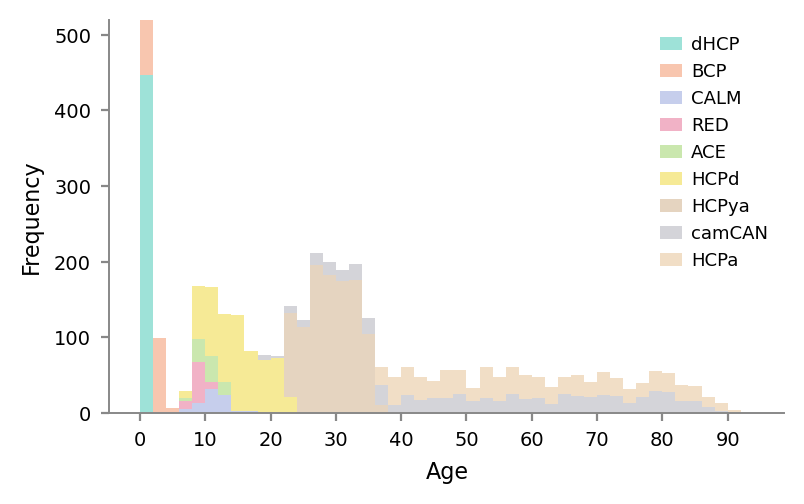

Saved.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ── Dataset mapping ───────────────────────────────────────────────────────────
DS_NAMES = {
    1: 'dHCP',
    2: 'BCP',
    3: 'CALM',
    4: 'RED',
    5: 'ACE',
    6: 'HCPd',
    7: 'HCPya',
    8: 'camCAN',
    9: 'HCPa',
}

# Colors matching the figure (order: dHCP, BCP, CALM, RED, ACE, HCPd, HCPya, camCAN, HCPa)
DS_COLORS = {
    1: '#5ecfbe',   # teal      – dHCP
    2: '#f4a07a',   # salmon    – BCP
    3: '#a0aee0',   # blue-grey – CALM
    4: '#e87fa0',   # pink      – RED
    5: '#a8d878',   # green     – ACE
    6: '#f0dc50',   # yellow    – HCPd
    7: '#d4b896',   # tan       – HCPya
    8: '#b8b8c0',   # grey      – camCAN
    9: '#e8c8a0',   # peach     – HCPa
}



# ── Replace with your real data ───────────────────────────────────────────────
data = pd.read_pickle('procdata/data.pkl')   # uncomment when using real data

# ── Plot ──────────────────────────────────────────────────────────────────────
BINS     = np.arange(0, 96, 2)         # 2-year bins  (change to match real data)
BAR_ALPHA = 0.60

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif':['DejaVu Sans'],  # Change to 'Open Sans' if you have it installed
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'figure.dpi': 200,
})

fig, ax = plt.subplots(figsize=(4,2.5))

# Stack datasets bottom-up
bottoms = np.zeros(len(BINS) - 1)

for ds in range(1, 10):
    sub  = data[data.dataset == ds]['age'].values
    hist, _ = np.histogram(sub, bins=BINS)
    ax.bar(
        BINS[:-1], hist,
        width=np.diff(BINS),
        bottom=bottoms,
        color=DS_COLORS[ds],
        alpha=BAR_ALPHA,
        align='edge',
        linewidth=0,
        label=DS_NAMES[ds],
    )
    bottoms = bottoms + hist

# ── Axes styling ──────────────────────────────────────────────────────────────
ax.set_xlabel('Age', labelpad=4)
ax.set_ylabel('Frequency', labelpad=4)

ax.set_xticks(np.arange(0, 100, 10))
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_linewidth(0.7)
ax.spines[['left', 'bottom']].set_color('#888888')
ax.tick_params(length=3, color='#888888')

# ── Legend ────────────────────────────────────────────────────────────────────
handles = [Patch(facecolor=DS_COLORS[ds], alpha=BAR_ALPHA, label=DS_NAMES[ds])
           for ds in range(1, 10)]
ax.legend(
    handles=handles,
    fontsize=6.5,
    frameon=False,
    loc='upper right',
    ncol=1,
    handlelength=1.2,
    handletextpad=0.5,
)

plt.tight_layout(pad=0.8)
plt.savefig('borradorv1/age_distribution.png',
            dpi=250, bbox_inches='tight'
            )
plt.show()
print("Saved.")

## Plotting functions

In [ ]:

def _logbins_hist(vals, n_bins=25):
    """Histograma en escala log con centros geométricos. Devuelve (centros, densidad)."""
    vals = vals[vals > 0]
    if len(vals) < 2:
        return np.array([]), np.array([])
    bins = np.logspace(np.log10(vals.min() + 1e-15),
                       np.log10(vals.max() + 1e-15), n_bins + 1)
    h, e = np.histogram(vals, bins=bins, density=True)
    c = np.sqrt(e[:-1] * e[1:])
    return c[h > 0], h[h > 0]
 

def plot_distributions(subjects, ax_pw, ax_ps, ax_cpk, ax_sk,
                       color='steelblue', alpha=0.5, ms=2, lw=0.8,
                       ks_ref=None, show_Y0=True):
    """
    Acumula distribuciones normalizadas y dibuja mediana ± IQR (banda).
    Normalización: w/w_max, s/s_max por sujeto. x de CCDF y s(k): k/k_max.
    """
    pw_acc  = defaultdict(list)   # bin_center → list of densities
    ps_acc  = defaultdict(list)
    pk_acc  = defaultdict(list)
    sk_acc  = defaultdict(list)

    W_BINS = np.logspace(-4, 0, 26)   # normalized bins [0,1]
    S_BINS = np.logspace(-4, 0, 26)

    for row in subjects:
        adj = (row.connectome if hasattr(row, 'connectome') else row).copy()
        np.fill_diagonal(adj, 0)
        k, s, Yi, kYi, wi = node_metrics(adj)
        w = adj[adj > 0]; v = k > 1
        if v.sum() == 0:
            continue

        wmax = w.max() if w.max() > 0 else 1
        smax = s[v].max() if s[v].max() > 0 else 1
        kmax = k[v].max() if k[v].max() > 0 else 1

        # P(w) normalized
        wn = w / wmax
        h, e = np.histogram(wn[wn > 0], bins=W_BINS, density=True)
        c = np.sqrt(e[:-1] * e[1:])
        for ci, hi in zip(c[h > 0], h[h > 0]):
            pw_acc[ci].append(hi)

        # P(s) normalized
        sn = s[v] / smax
        h, e = np.histogram(sn[sn > 0], bins=S_BINS, density=True)
        c = np.sqrt(e[:-1] * e[1:])
        for ci, hi in zip(c[h > 0], h[h > 0]):
            ps_acc[ci].append(hi)

        # CCDF and s(k) — k normalized by k_max
        ku, kc = np.unique(k[v].astype(int), return_counts=True)
        pk = kc / kc.sum()
        for ki, pi in zip(ku, pk):
            pk_acc[ki / kmax].append(pi)
            sk_acc[ki / kmax].append(s[k == ki].mean() / smax)

    def _plot_band(ax, acc_dict, color, alpha, lw):
        if not acc_dict:
            return
        xs = np.array(sorted(acc_dict))
        med = np.array([np.median(acc_dict[x]) for x in xs])
        q25 = np.array([np.percentile(acc_dict[x], 25) for x in xs])
        q75 = np.array([np.percentile(acc_dict[x], 75) for x in xs])
        ax.loglog(xs, med, '-', lw=lw + 0.2, alpha=min(alpha + 0.3, 1), color=color)
        ax.fill_between(xs, q25, q75, alpha=alpha * 0.4, color=color, linewidth=0)

    # CCDF needs cumulative from sorted k/k_max
    if pk_acc:
        ks = np.array(sorted(pk_acc))
        pk_med = np.array([np.median(pk_acc[x]) for x in ks])
        pk_q25 = np.array([np.percentile(pk_acc[x], 25) for x in ks])
        pk_q75 = np.array([np.percentile(pk_acc[x], 75) for x in ks])
        ccdf_med = np.cumsum(pk_med[::-1])[::-1]
        ccdf_q25 = np.cumsum(pk_q25[::-1])[::-1]
        ccdf_q75 = np.cumsum(pk_q75[::-1])[::-1]
        ccdf_med = ccdf_med / ccdf_med.max()   # fuerza a empezar en 1
        ccdf_q25 = ccdf_q25 / ccdf_q25.max()
        ccdf_q75 = ccdf_q75 / ccdf_q75.max()

        ax_cpk.loglog(ks, ccdf_med, '-', lw=lw + 0.2,
                      alpha=min(alpha + 0.3, 1), color=color)
        ax_cpk.fill_between(ks, ccdf_q25, ccdf_q75,
                            alpha=alpha * 0.4, color=color, linewidth=0)

    _plot_band(ax_pw, pw_acc, color, alpha, lw)
    _plot_band(ax_ps, ps_acc, color, alpha, lw)
    _plot_band(ax_sk, sk_acc, color, alpha, lw)

    ax_pw.set_xlabel('$w/w_{max}$');     ax_pw.set_ylabel('$P(w)$')
    ax_ps.set_xlabel('$s/s_{max}$');     ax_ps.set_ylabel('$P(s)$')
    ax_cpk.set_xlabel('$k/k_{max}$');    ax_cpk.set_ylabel('$P(K\\geq k)$')
    ax_sk.set_xlabel('$k/k_{max}$');     ax_sk.set_ylabel('$\\langle s/s_{max}\\rangle_k$')

def distributions_fig(groups, 
                      figsize=None, savepath=None):
    """
    Figura de distribuciones para múltiples grupos superpuestos.
    Paneles: P(k) | P(w) | P(s) | Y(k) [| kP(k)] [| CCDF(k)]
    Paneles:  P(w) | P(s) | CCDF(k) | S(k)

    groups : lista de dicts con claves:
        'subjects' : iterable de filas (pd.Series con .connectome) o matrices 90×90
        'color'    : color matplotlib
        'label'    : string para la leyenda
        'alpha'    : transparencia (default 0.5)
        'ms'       : markersize (default 2)
        'lw'       : linewidth (default 0.8)
    """
    fig, axs = plt.subplots(2, 2, figsize=figsize)
 
    ax_pw  = axs[0][0]
    ax_ps  = axs[0][1]
    ax_cpk = axs[1][0]
    ax_sk= axs[1][1] 
 
    for g in groups:
        plot_distributions(
            g['subjects'], ax_pw, ax_ps, ax_cpk, ax_sk,
            color=g.get('color', 'steelblue'),
            alpha=g.get('alpha', 0.5),
            ms=g.get('ms', 2),
            lw=g.get('lw', 0.8),
            show_Y0=False,
        )
 
 
    # shared legend
    handles = [plt.Line2D([0], [0], color=g['color'], lw=1.5, label=g['label'])
               for g in groups]
    fig.legend(handles=handles, loc='lower center', ncol=len(groups),
               fontsize=5, bbox_to_anchor=(0.5, -0.08))
 
    plt.tight_layout(pad=0.4)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    return fig, axs
 

# Histogramas de nodos por datasets

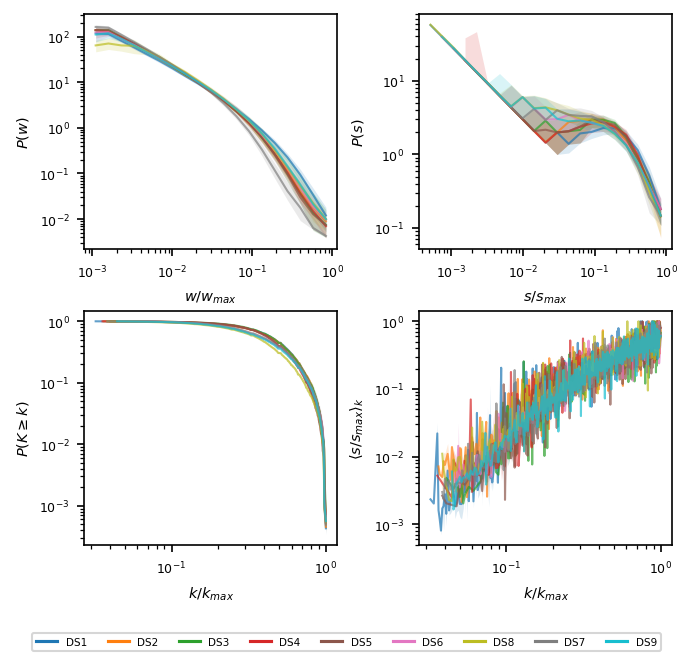


Ahora con los Group Representatives por dataset (DDW):


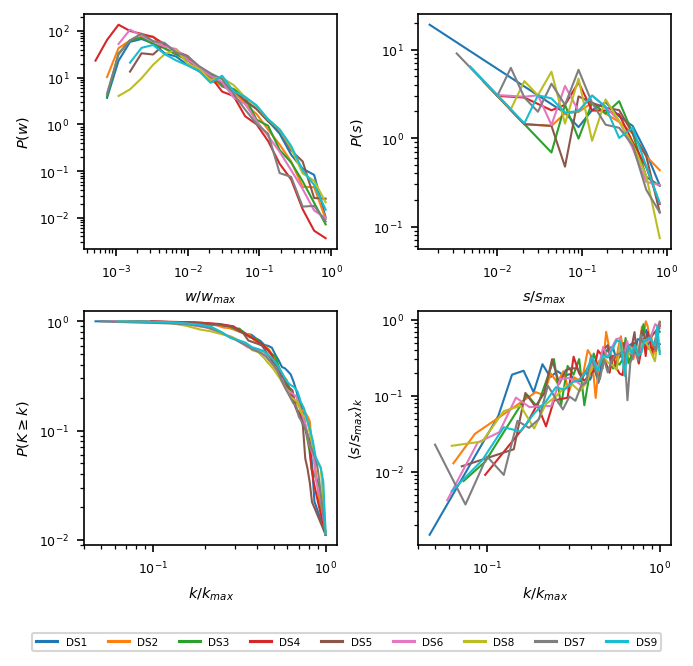

In [ ]:
# ── CELDA 6: FIG 3 — P(k)/P(w)/P(s)/Y(k), un sujeto por dataset ─────────────
# Selección: sujeto a la edad mediana por (dataset, sexo)
groups = [{'subjects': data[data.dataset==ds].itertuples(),
           'color': ds2col[ds], 'label': f'DS{ds}', 'alpha':0.4}
          for ds in compare_ds if ds in ds_list]
distributions_fig(groups,figsize=(4.5,4), savepath='borradorv1/fig3_distributions_ds.pdf')
plt.show()

print("\nAhora con los Group Representatives por dataset (DDW):")

groups_grepp = [{'subjects': [grep_ds[ds]], 'color': ds2col[ds],
           'label': f'DS{ds}', 'alpha':0.9, 'ms':3}
          for ds in compare_ds]
distributions_fig(groups_grepp,figsize=(4.5,4), savepath='borradorv1/fig3_grep_distributions_ds.pdf')
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Open Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Open Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Open Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Open Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Open Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Open Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Open Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Open Sans
findfont: Generic family 'sans-serif' not found because none of the following families were found: Open Sans
findfont: Generic f

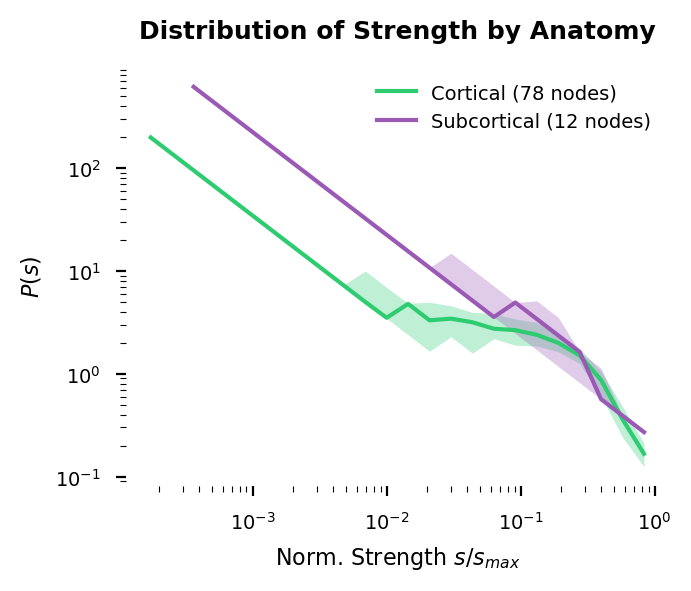

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Índices subcorticales típicos para AAL90 (0-indexed)
SUBCORTICAL_IDX = np.array([36, 37, 38, 39, 70, 71, 72, 73, 74, 75, 76, 77])

def plot_ps_anatomical_split(subjects, ax, color_cort='#2ecc71', color_subc='#9b59b6'):
    ps_cort_acc = defaultdict(list)
    ps_subc_acc = defaultdict(list)
    S_BINS = np.logspace(-4, 0, 26)

    for row in subjects:
        adj = (row.connectome if hasattr(row, 'connectome') else row).copy()
        np.fill_diagonal(adj, 0)
        
        # Calculamos la fuerza bruta
        s = adj.sum(axis=1)
        if s.max() == 0: continue
            
        # Normalizamos por el máximo global del sujeto (como en tu plot general)
        s_norm = s / s.max()
        
        # Máscaras booleanas
        mask_subc = np.zeros(90, dtype=bool)
        mask_subc[SUBCORTICAL_IDX] = True
        mask_cort = ~mask_subc
        
        # Separar valores
        s_cort = s_norm[mask_cort & (s_norm > 0)]
        s_subc = s_norm[mask_subc & (s_norm > 0)]
        
        # Histograma Cortical
        if len(s_cort) > 0:
            h, e = np.histogram(s_cort, bins=S_BINS, density=True)
            c = np.sqrt(e[:-1] * e[1:])
            for ci, hi in zip(c[h > 0], h[h > 0]):
                ps_cort_acc[ci].append(hi)
                
        # Histograma Subcortical
        if len(s_subc) > 0:
            h, e = np.histogram(s_subc, bins=S_BINS, density=True)
            c = np.sqrt(e[:-1] * e[1:])
            for ci, hi in zip(c[h > 0], h[h > 0]):
                ps_subc_acc[ci].append(hi)

    def _plot_band(ax, acc_dict, color, label):
        if not acc_dict: return
        xs = np.array(sorted(acc_dict))
        med = np.array([np.median(acc_dict[x]) for x in xs])
        q25 = np.array([np.percentile(acc_dict[x], 25) for x in xs])
        q75 = np.array([np.percentile(acc_dict[x], 75) for x in xs])
        
        ax.loglog(xs, med, '-', lw=1.5, color=color, label=label)
        ax.fill_between(xs, q25, q75, alpha=0.3, color=color, linewidth=0)

    _plot_band(ax, ps_cort_acc, color_cort, 'Cortical (78 nodes)')
    _plot_band(ax, ps_subc_acc, color_subc, 'Subcortical (12 nodes)')

    ax.set_xlabel('Norm. Strength $s/s_{max}$', fontsize=8)
    ax.set_ylabel('$P(s)$', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(frameon=False, fontsize=7)

# --- Crear la figura aislando este análisis ---
fig, ax = plt.subplots(figsize=(3.5, 3))

# Le pasamos todos los sujetos (o puedes filtrarlo por un dataset concreto si quieres)
plot_ps_anatomical_split(data.itertuples(), ax)

ax.set_title('Distribution of Strength by Anatomy', fontsize=9, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('borradorv1/fig_ps_cortical_vs_subcortical.pdf', bbox_inches='tight', dpi=300)
plt.show()

Generando distribuciones para Datos Crudos...


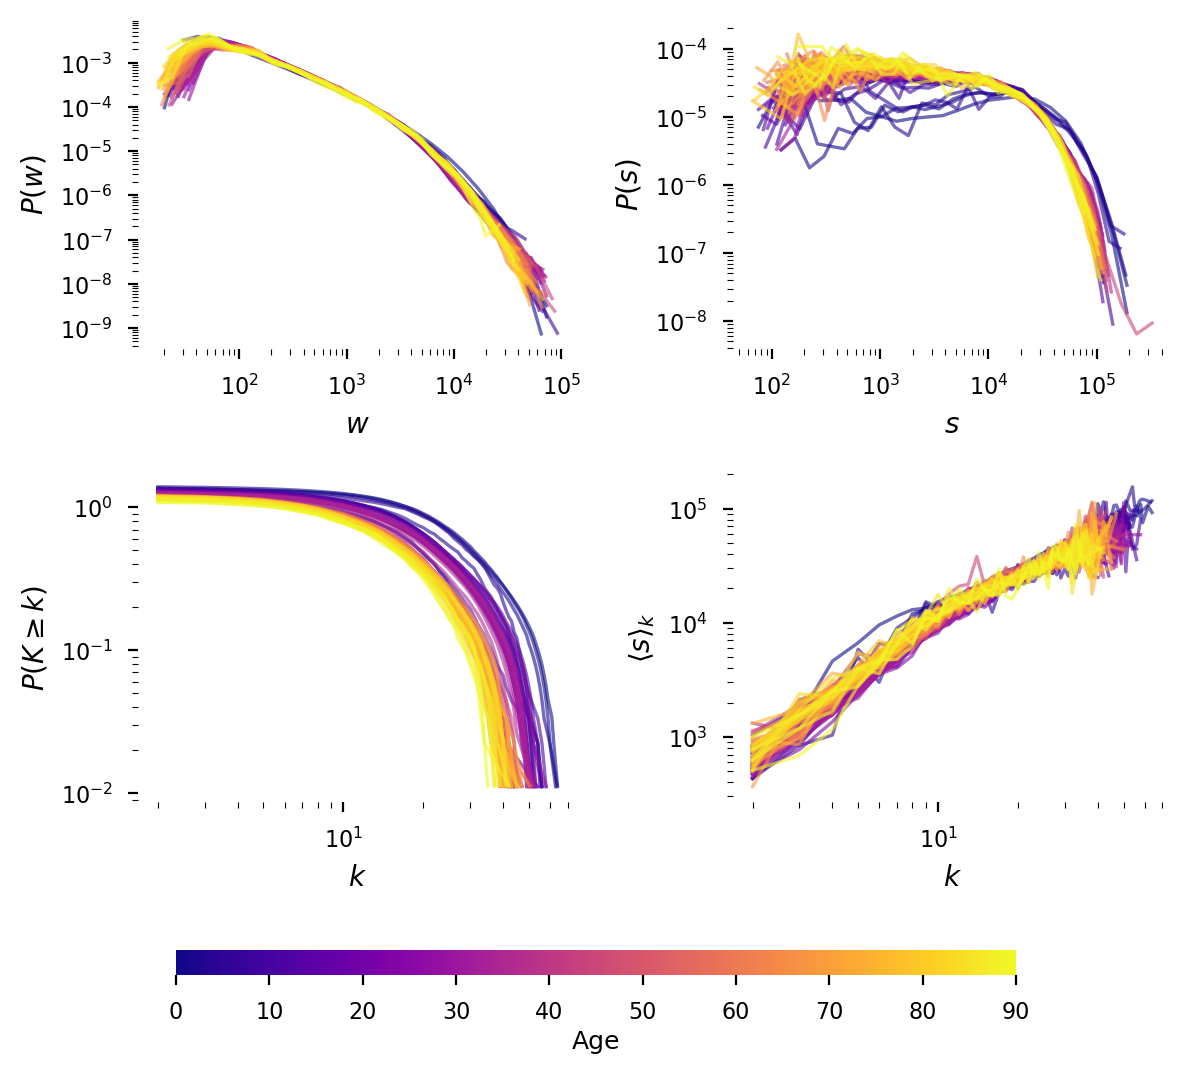

Generando distribuciones para Group Representatives DDW...


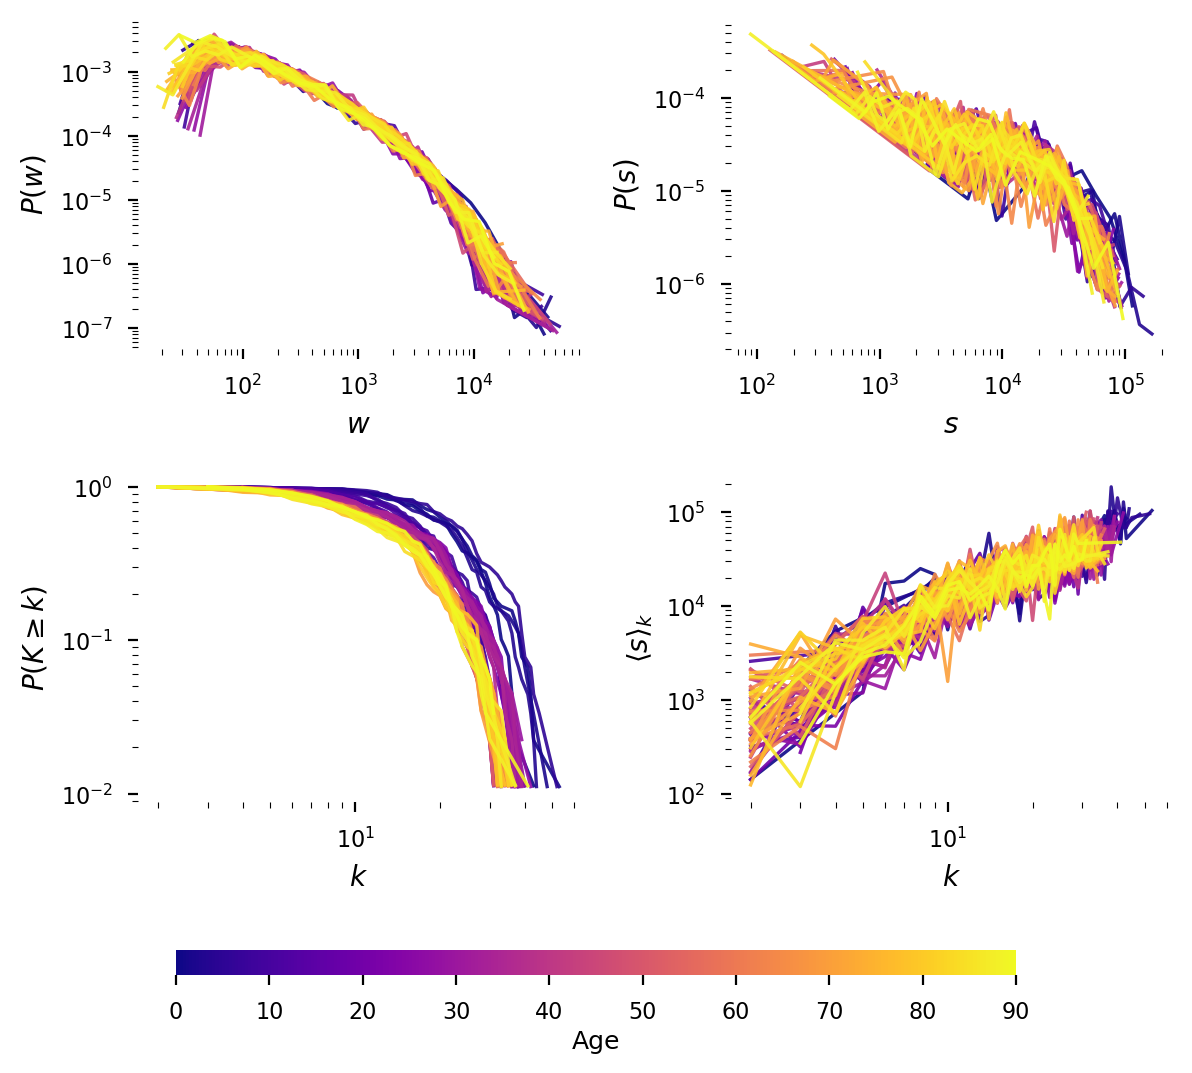

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict

# Asumo que _logbins_hist, node_metrics y ddw_group_rep están importadas de helperfuncs
# from helperfuncs import _logbins_hist, node_metrics, ddw_group_rep

MIN_N = 3

def plot_distributions_pooled(subjects, ax_pw, ax_ps, ax_cpk, ax_sk,
                              color='steelblue', alpha=0.8, lw=1.2):
    """
    Basado en tu función original. 
    Dibuja UNA sola curva agrupando todos los sujetos de la lista (por edad).
    """
    all_w, all_s = [], []
    pk_acc = defaultdict(list)
    sk_acc = defaultdict(list)

    for row in subjects:
        adj = (row.connectome if hasattr(row, 'connectome') else row).copy()
        np.fill_diagonal(adj, 0)
        k, s, Yi, kYi, wi = node_metrics(adj)
        w = adj[adj > 0]; v = k > 1
        if v.sum() == 0: continue

        # Acumulamos para hacer el histograma global de la edad
        all_w.extend(w)
        all_s.extend(s[v])
        
        ku, kc = np.unique(k[v].astype(int), return_counts=True)
        pk = kc / kc.sum()
        for ki, pi in zip(ku, pk):
            pk_acc[ki].append(pi)
            sk_acc[ki].append(s[k == ki].mean())

    # P(w)
    if len(all_w) > 0:
        cx, hx = _logbins_hist(np.array(all_w))
        if len(cx): ax_pw.loglog(cx, hx, '-', lw=lw, alpha=alpha, color=color)

    # P(s)
    if len(all_s) > 0:
        cx, hx = _logbins_hist(np.array(all_s))
        if len(cx): ax_ps.loglog(cx, hx, '-', lw=lw, alpha=alpha, color=color)

    # CCDF(k) y s(k)
    if pk_acc:
        ks_sorted = np.array(sorted(pk_acc))
        pk_mean   = np.array([np.mean(pk_acc[ki]) for ki in ks_sorted])
        sk_mean   = np.array([np.mean(sk_acc[ki]) for ki in ks_sorted])
        
        # CCDF P(K >= k) — x axis raw (sin dividir por k_max)
        ccdf = np.cumsum(pk_mean[::-1])[::-1]
        ax_cpk.loglog(ks_sorted, ccdf, '-', lw=lw, alpha=alpha, color=color)
        
        # s(k) — x axis raw
        ax_sk.loglog(ks_sorted, sk_mean, '-', lw=lw, alpha=alpha, color=color)


def gradient_distributions_fig(df, is_grep=False, savepath=None):
    """
    Figura de distribuciones 2x2 con gradiente de color por edad.
    Estilo emparejado a la imagen de referencia (cajas cerradas, leyenda inferior).
    """
    fig, axs = plt.subplots(2, 2, figsize=(6, 5))
    ax_pw, ax_ps = axs[0]
    ax_cpk, ax_sk = axs[1]
    
    ages_valid = sorted([a for a in df.age.unique() if len(df[df.age == a]) >= MIN_N])
    vmin, vmax = min(ages_valid), max(ages_valid)
    
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.plasma  # Puedes cambiar a 'viridis' si lo prefieres
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    
    for age in ages_valid:
        sub = df[df.age == age]
        color = cmap(norm(age))
        
        if is_grep:
            # Group representative por edad
            gr = ddw_group_rep(list(sub.connectome), dist_mat, hemi, N_BINS, rng_ddw)
            # Se le pasa dentro de una lista para que el bucle itere una vez
            plot_distributions_pooled([gr], ax_pw, ax_ps, ax_cpk, ax_sk, 
                                      color=color, alpha=0.9, lw=1.2)
        else:
            # Iterador de las filas para procesar todos los sujetos
            plot_distributions_pooled(sub.itertuples(), ax_pw, ax_ps, ax_cpk, ax_sk, 
                                      color=color, alpha=0.6, lw=1.2)

    # Etiquetas idénticas a la imagen de referencia
    ax_pw.set_ylabel(r'$P(w)$', fontsize=10)
    ax_pw.set_xlabel(r'$w$', fontsize=10)
    
    ax_ps.set_ylabel(r'$P(s)$', fontsize=10)
    ax_ps.set_xlabel(r'$s$', fontsize=10)
    
    ax_cpk.set_ylabel(r'$P(K \geq k)$', fontsize=10)
    ax_cpk.set_xlabel(r'$k$', fontsize=10)
    
    ax_sk.set_ylabel(r'$\langle s \rangle_k$', fontsize=10)
    ax_sk.set_xlabel(r'$k$', fontsize=10)
    
    # Formato de la caja (sin despine para mantener el recuadro negro)
    for ax in axs.flat:
        ax.tick_params(axis='both', which='both', direction='out', labelsize=8)
        
    # Dejamos espacio en la parte inferior para la colorbar (como en tu imagen)
    plt.tight_layout(rect=[0, 0.08, 1, 1], h_pad=1.5, w_pad=1.5)
    
    # Añadimos la colorbar anclada al fondo
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.025])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label('Age', fontsize=9, labelpad=2)
    cbar.ax.tick_params(labelsize=8)
    
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=300)
    plt.show()

# =============================================================================
# EJECUCIÓN
# =============================================================================

print("Generando distribuciones para Datos Crudos...")
gradient_distributions_fig(data, is_grep=False, savepath='borradorv1/fig3_dist_raw_grad.pdf')

print("Generando distribuciones para Group Representatives DDW...")
gradient_distributions_fig(data, is_grep=True, savepath='borradorv1/fig3_dist_grep_grad.pdf')

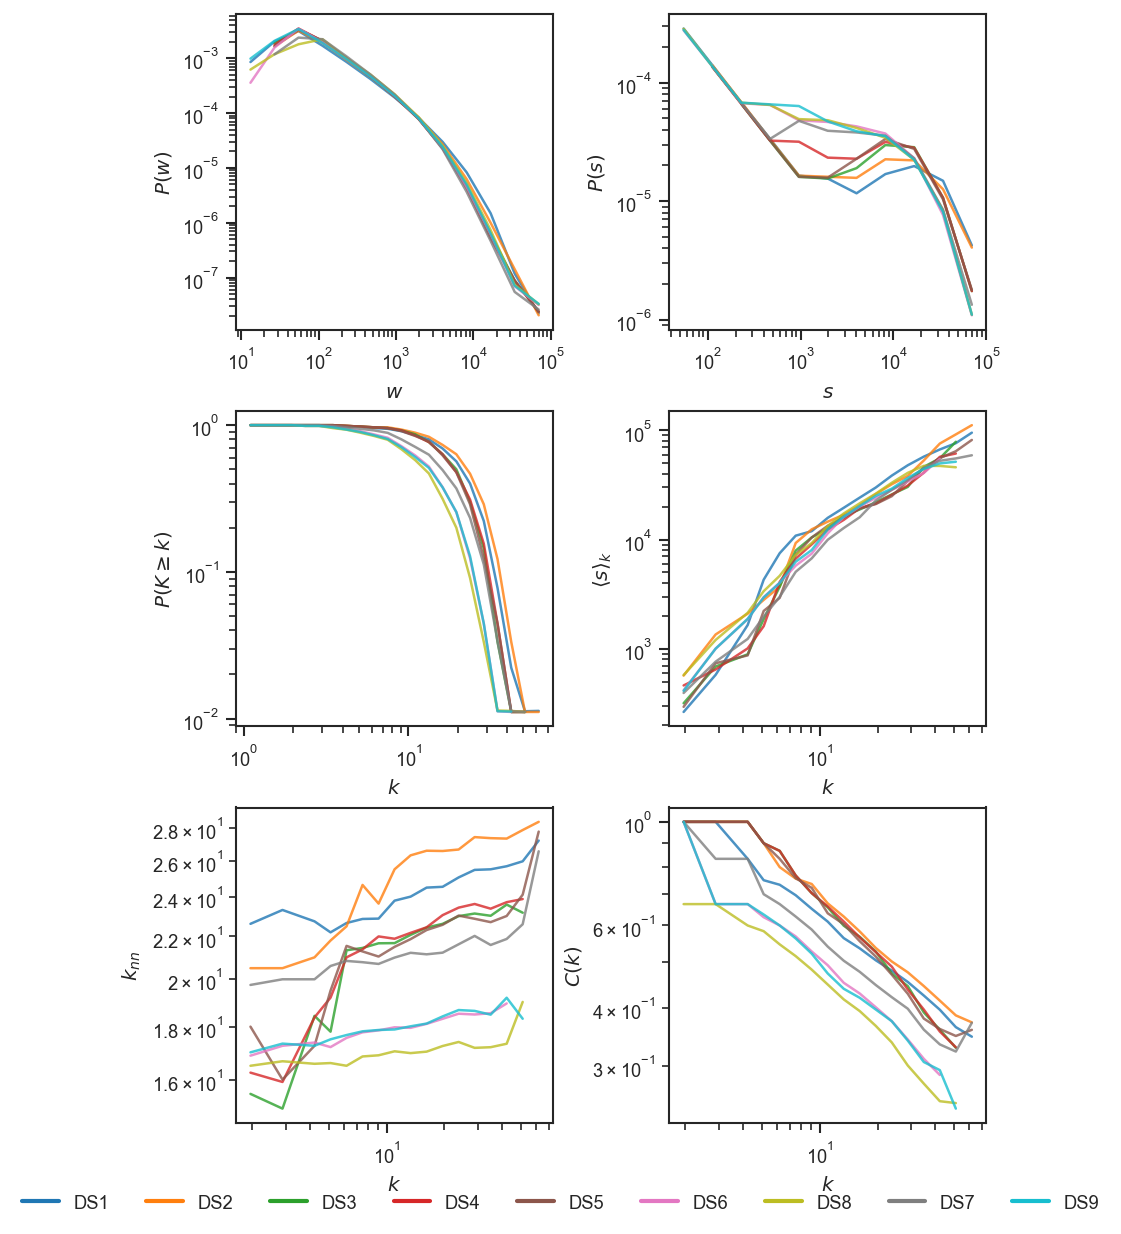

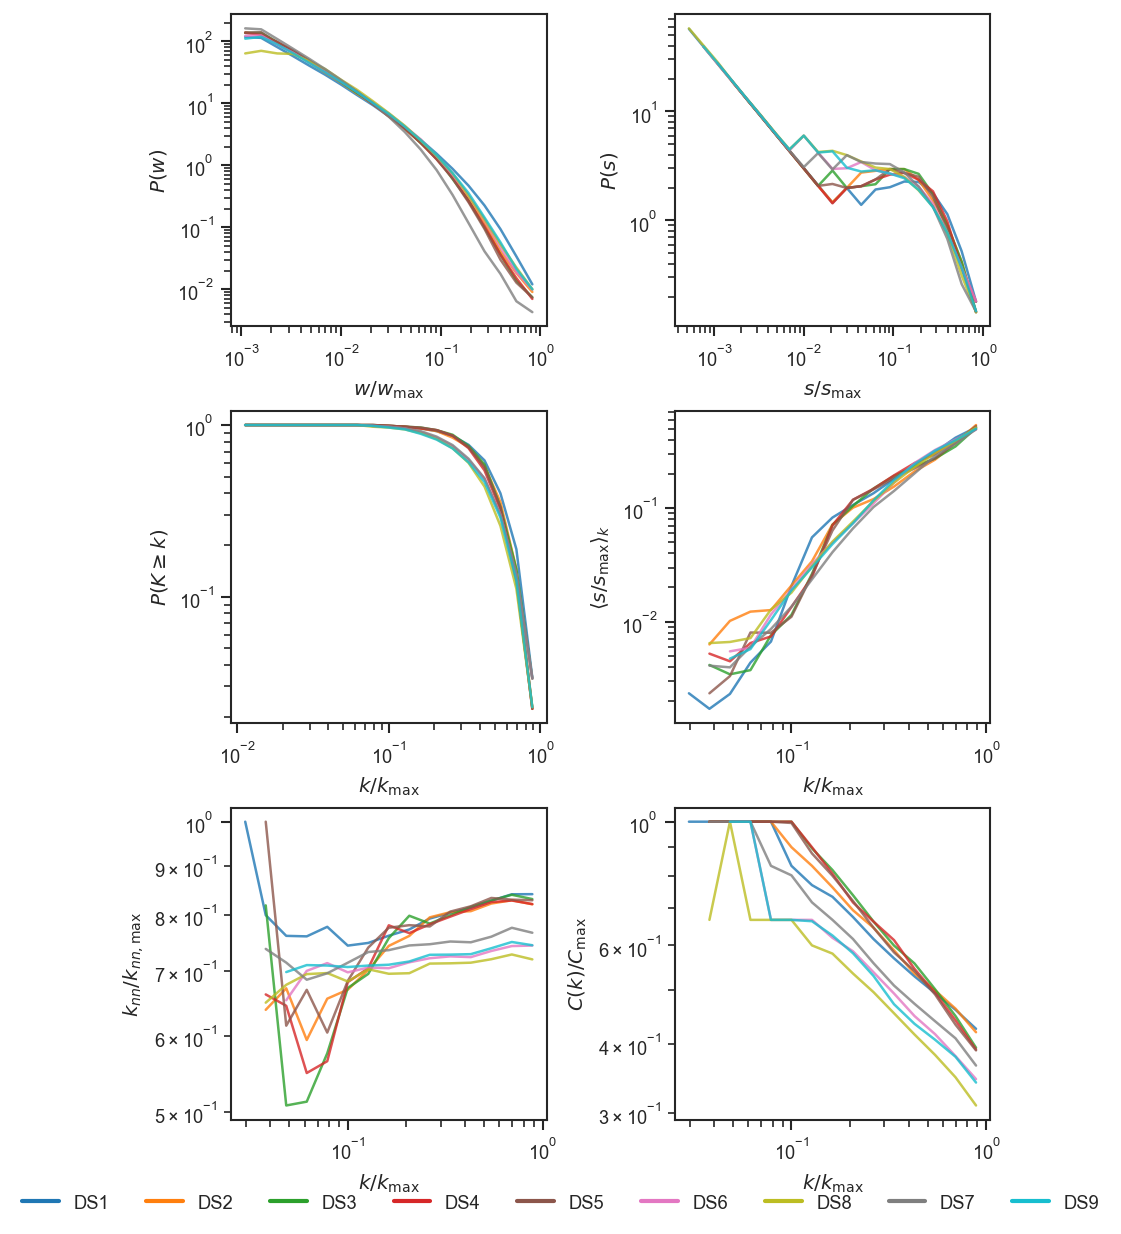

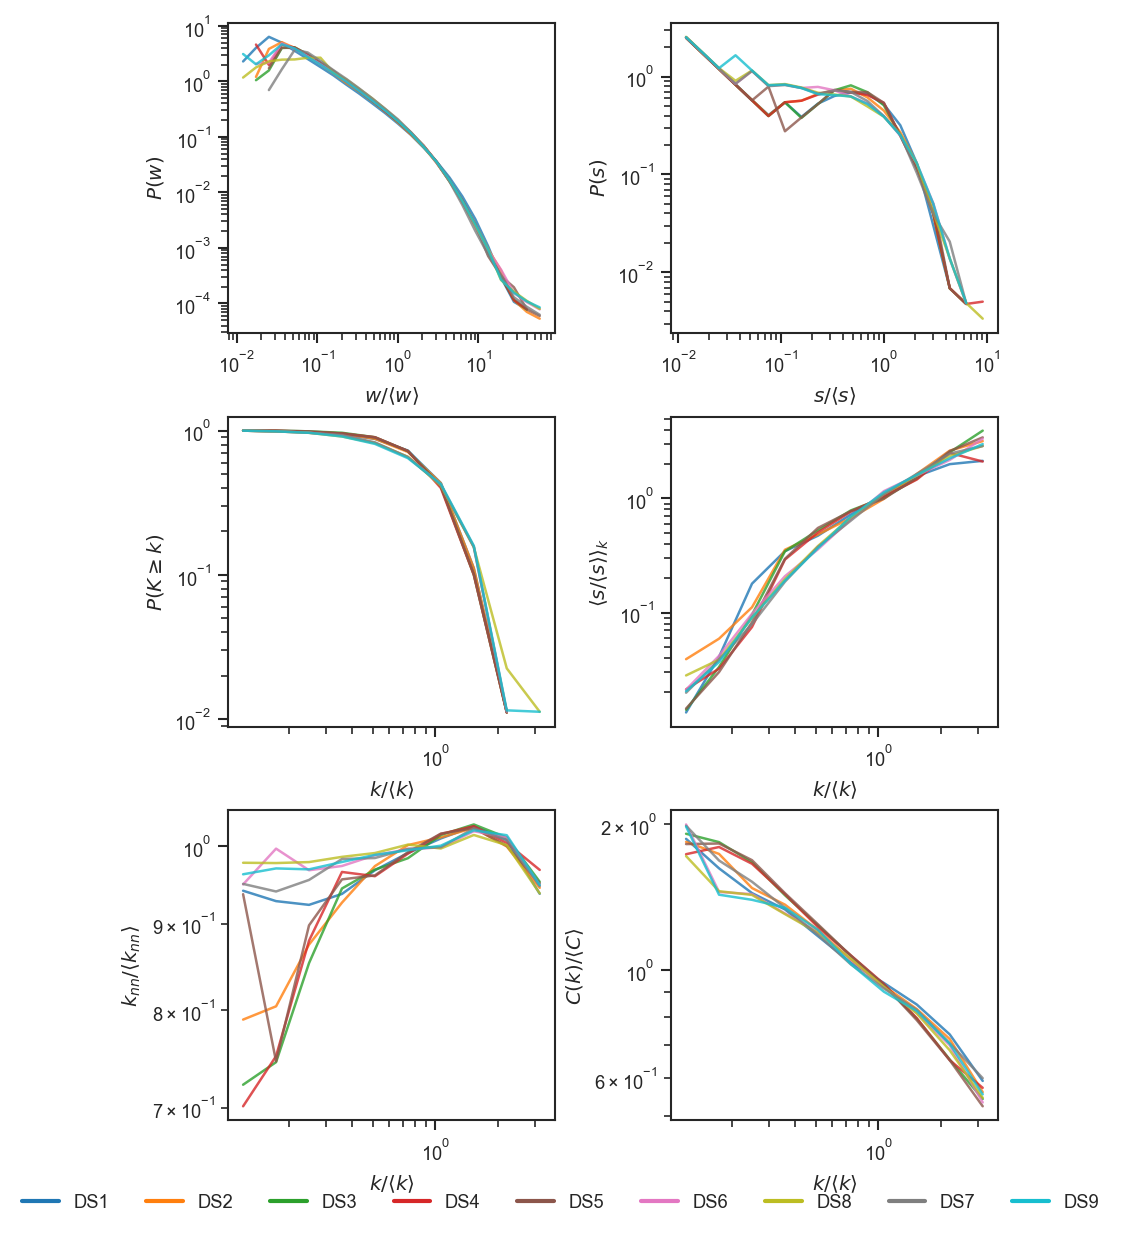

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

sns.set_theme(style="ticks", context="paper")

def _get_fixed_bins(norm, is_k=False):
    """Genera bines fijos. Para k, el mínimo normalizado por max es ~0.01."""
    if norm == 'max':
        return np.logspace(-2, 0, 20) if is_k else np.logspace(-4, 0, 26)
    elif norm == 'mean':
        return np.logspace(-1, 2, 20) if is_k else np.logspace(-2, 2, 26)
    else:  # raw
        return np.logspace(0, 2, 25) if is_k else np.logspace(-4, 5, 30)

def _binned_mean(x, y, bins):
    centers = np.sqrt(bins[:-1] * bins[1:])
    idx = np.digitize(x, bins) - 1
    y_binned = {}
    for i, c in enumerate(centers):
        mask = (idx == i)
        if np.any(mask):
            y_binned[c] = np.mean(y[mask])
    return y_binned

def plot_distributions_v3(subjects, ax_pw, ax_ps, ax_cpk, ax_sk, ax_knn, ax_ck,
                          norm='max', color='steelblue', alpha=0.8, lw=1.2):
    pw_acc  = defaultdict(list); ps_acc  = defaultdict(list)
    cpk_acc = defaultdict(list); sk_acc  = defaultdict(list)
    knn_acc = defaultdict(list); ck_acc  = defaultdict(list)

    bins_w = _get_fixed_bins(norm)
    bins_s = _get_fixed_bins(norm)
    bins_k = _get_fixed_bins(norm, is_k=True)
    centers_k = np.sqrt(bins_k[:-1] * bins_k[1:])

    for row in subjects:
        adj = (row.connectome if hasattr(row, 'connectome') else row).copy()
        np.fill_diagonal(adj, 0)
        G = nx.from_numpy_array(adj)

        # Asume node_metrics accesible en el scope
        k, s, Yi, kYi, wi = node_metrics(adj)
        w = adj[adj > 0]; v = k > 1
        if v.sum() == 0:
            continue

        wref = {'raw': 1, 'max': w.max() or 1, 'mean': w.mean() or 1}[norm]
        sref = {'raw': 1, 'max': s[v].max() or 1, 'mean': s[v].mean() or 1}[norm]
        kref = {'raw': 1, 'max': k[v].max() or 1, 'mean': k[v].mean() or 1}[norm]

        knn_d = nx.average_neighbor_degree(G, weight=None)
        clust_d = nx.clustering(G, weight=None)
        
        knn_vals = np.array([knn_d[n] for n in range(len(k)) if k[n] > 1])
        ck_vals  = np.array([clust_d[n] for n in range(len(k)) if k[n] > 1])
        
        knn_ref = {'raw': 1, 'max': knn_vals.max() if len(knn_vals) else 1, 
                             'mean': knn_vals.mean() if len(knn_vals) else 1}[norm]
        ck_ref  = {'raw': 1, 'max': ck_vals.max() if len(ck_vals) else 1,   
                             'mean': ck_vals.mean() if len(ck_vals) else 1}[norm]

        # Distribuciones continuas en bines
        wn = w / wref
        hw, ew = np.histogram(wn[wn > 0], bins=bins_w, density=True)
        cw = np.sqrt(ew[:-1] * ew[1:])
        for ci, hi in zip(cw[hw > 0], hw[hw > 0]):
            pw_acc[ci].append(hi)

        sn = s[v] / sref
        hs, es = np.histogram(sn[sn > 0], bins=bins_s, density=True)
        cs = np.sqrt(es[:-1] * es[1:])
        for ci, hi in zip(cs[hs > 0], hs[hs > 0]):
            ps_acc[ci].append(hi)

        # CCDF exacta agrupada por los centros discretos válidos
        kn = k[v] / kref
        for c in centers_k:
            prob = np.mean(kn >= c)
            if prob > 0:
                cpk_acc[c].append(prob)

        # Métricas promediadas por los bines de k
        sn_k = s[v] / sref
        for c, val in _binned_mean(kn, sn_k, bins_k).items():
            sk_acc[c].append(val)

        knn_n = knn_vals / knn_ref
        for c, val in _binned_mean(kn, knn_n, bins_k).items():
            knn_acc[c].append(val)

        ck_n = ck_vals / ck_ref
        for c, val in _binned_mean(kn, ck_n, bins_k).items():
            ck_acc[c].append(val)

    def _plot_median(ax, acc):
        if not acc: return
        xs  = np.array(sorted(acc))
        med = np.array([np.median(acc[x]) for x in xs])
        mask = med > 0
        ax.loglog(xs[mask], med[mask], '-', lw=lw, alpha=alpha, color=color)

    _plot_median(ax_pw,  pw_acc)
    _plot_median(ax_ps,  ps_acc)
    _plot_median(ax_cpk, cpk_acc)
    _plot_median(ax_sk,  sk_acc)
    _plot_median(ax_knn, knn_acc)
    _plot_median(ax_ck,  ck_acc)

    xlabels = {
        'raw':  (r'$w$', r'$s$', r'$k$', r'$k$', r'$k$', r'$k$'),
        'max':  (r'$w/w_{\max}$', r'$s/s_{\max}$', r'$k/k_{\max}$', r'$k/k_{\max}$', r'$k/k_{\max}$', r'$k/k_{\max}$'),
        'mean': (r'$w/\langle w\rangle$', r'$s/\langle s\rangle$', r'$k/\langle k\rangle$', r'$k/\langle k\rangle$', r'$k/\langle k\rangle$', r'$k/\langle k\rangle$'),
    }[norm]

    ylabels_sk = {'raw': r'$\langle s \rangle_k$', 'max': r'$\langle s/s_{\max}\rangle_k$', 'mean': r'$\langle s/\langle s\rangle\rangle_k$'}[norm]
    ylabels_knn = {'raw': r'$k_{nn}$', 'max': r'$k_{nn}/k_{nn,\max}$', 'mean': r'$k_{nn}/\langle k_{nn}\rangle$'}[norm]
    ylabels_ck = {'raw': r'$C(k)$', 'max': r'$C(k)/C_{\max}$', 'mean': r'$C(k)/\langle C\rangle$'}[norm]

    ax_pw.set(xlabel=xlabels[0], ylabel=r'$P(w)$')
    ax_ps.set(xlabel=xlabels[1], ylabel=r'$P(s)$')
    ax_cpk.set(xlabel=xlabels[2], ylabel=r'$P(K\geq k)$')
    ax_sk.set(xlabel=xlabels[3], ylabel=ylabels_sk)
    ax_knn.set(xlabel=xlabels[4], ylabel=ylabels_knn)
    ax_ck.set(xlabel=xlabels[5], ylabel=ylabels_ck)

def distributions_fig_v3(groups, norm='max', figsize=(6, 8), savepath=None):
    fig, axs = plt.subplots(3, 2, figsize=figsize)
    
    for g in groups:
        plot_distributions_v3(
            g['subjects'], *axs.flat,
            norm=norm, color=g.get('color', 'steelblue'),
            alpha=g.get('alpha', 0.8), lw=g.get('lw', 1.2)
        )

    handles = [plt.Line2D([0], [0], color=g['color'], lw=2, label=g['label']) for g in groups]
    fig.legend(handles=handles, loc='lower center', ncol=len(groups), bbox_to_anchor=(0.5, -0.02), frameon=False)
    
    plt.tight_layout(pad=0.5)
    if savepath:
        plt.savefig(savepath, bbox_inches='tight')
    return fig, axs

# ── Ejecución ─────────────────────────────────────────────────────────────────
for norm in ('raw', 'max', 'mean'):
    grps = [{'subjects': data[data.dataset == ds].itertuples(),
             'color': ds2col[ds], 'label': f'DS{ds}', 'alpha': 0.8}
            for ds in compare_ds if ds in ds_list]
    
    distributions_fig_v3(grps, norm=norm, figsize=(6, 8),
                         savepath=f'borradorv1/fig3_distributions_ds_{norm}.pdf')
    plt.show()

En los grep por dataset coinciden mucho mejor las distribuciones (3,4 por ejemplo) pero los weigths más pequeños desaparecen muchos (menor consenso)

Se ve mucho mejor con los datos crudos. hay muchos menos puntos en los grep. Faltaría normalizarlos todos los plots

# kY(k) con el modelo nulo para todos los nodos. Falta lo mismo con los grep

Mean a (sigmas above null): 5.13
Median a:                   5.16


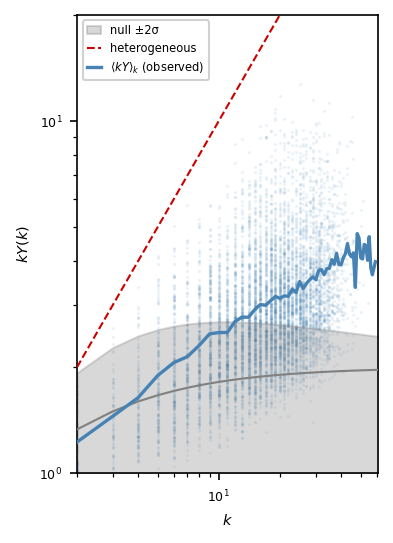

In [ ]:
# ── FIG paper: kY(k) todos los datasets, null model, línea media + σ annotation

MAX_SUBJ_PER_DS = 20
rng_fig = np.random.default_rng(42)

# ── acumular puntos y media por k (todos los datasets) ──────────────────────
all_k, all_kY = [], []
k_acc = defaultdict(list)   # para la media por clase de k

for ds in ds_list:
    sub = data[data.dataset==ds]
    sub = sub.iloc[rng_fig.choice(len(sub), min(MAX_SUBJ_PER_DS, len(sub)), replace=False)]
    for _, row in sub.iterrows():
        k, s, Yi, kYi, w = node_metrics(row.connectome)
        v = k > 1
        all_k.append(k[v]); all_kY.append(kYi[v])
        for ki in np.unique(k[v].astype(int)):
            k_acc[ki].extend(kYi[k == ki].tolist())

k_arr  = np.concatenate(all_k)
kY_arr = np.concatenate(all_kY)

# media y std observadas por clase de k
ks_obs    = np.array(sorted(k_acc))
kY_obs_mu = np.array([np.mean(k_acc[ki]) for ki in ks_obs])

# ── calcular a: cuántas sigmas sobre el null (interpolado en ks_obs) ─────────
null_mu  = np.interp(ks_obs, NUL['ks'], NUL['kY_null'])
null_hi  = np.interp(ks_obs, NUL['ks'], NUL['kY_hi'])
null_lo  = np.interp(ks_obs, NUL['ks'], NUL['kY_lo'])
null_sig = (null_hi - null_mu) / 2        # σ del null teórico (banda ±2σ → /2)
a_vals   = (kY_obs_mu - null_mu) / null_sig
a_mean   = np.nanmean(a_vals[null_sig > 0])
a_med    = np.nanmedian(a_vals[null_sig > 0])

print(f'Mean a (sigmas above null): {a_mean:.2f}')
print(f'Median a:                   {a_med:.2f}')

# ── figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(2.5,3.5))

# scatter (subsample para no saturar)
idx_sc = rng_fig.choice(len(k_arr), min(8000, len(k_arr)), replace=False)
ax.scatter(k_arr[idx_sc], kY_arr[idx_sc],
           s=0.4, alpha=0.08, color='steelblue', rasterized=True, zorder=1)

# null model
ax.fill_between(NUL['ks'], NUL['kY_lo'], NUL['kY_hi'],
                color='grey', alpha=0.3, zorder=2, label='null ±2σ')
ax.plot(NUL['ks'], NUL['kY_null'], '-',  color='grey',   lw=1,   zorder=3)

ax.plot(NUL['ks'], NUL['kY_het'],  '--', color='#cc0000', lw=1,   zorder=3,
        label='heterogeneous')

# línea media observada (todos los datasets)
ax.plot(ks_obs, kY_obs_mu, '-', color='steelblue', lw=1.6, zorder=5,
        label=r'$\langle kY\rangle_k$ (observed)')

# anotación de a
#ax.text(0.97, 0.77,
#        f'$\\bar{{a}} = {a_mean:.1f}\\,\\sigma$',
#        transform=ax.transAxes, fontsize=7,
#        ha='right', va='top',
#        bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(2, 61);  ax.set_ylim(1, 20)
ax.set_xlabel('$k$')
ax.set_ylabel(r'$kY(k)$')
ax.legend(fontsize=5.5, handlelength=1.2, loc='upper left',
          framealpha=0.9)

plt.tight_layout(pad=0.4)
plt.savefig('borradorv1/fig2b_kY_paper.png', bbox_inches='tight')
plt.show()

In [ ]:
# Contar nodos en cada k para ponderar
k_counts = np.array([len(k_acc[ki]) for ki in ks_obs])

# Filtrar válidos (donde sigma > 0)
valid = null_sig > 0

# Media ponderada
a_mean_weighted = np.average(a_vals[valid], weights=k_counts[valid])

print(f'Mean a (unweighted): {np.nanmean(a_vals[valid]):.2f}')
print(f'Mean a (weighted):   {a_mean_weighted:.2f}')

Mean a (unweighted): 5.13
Mean a (weighted):   3.11


# Weight evolution in stages. 0-20 and 20-80

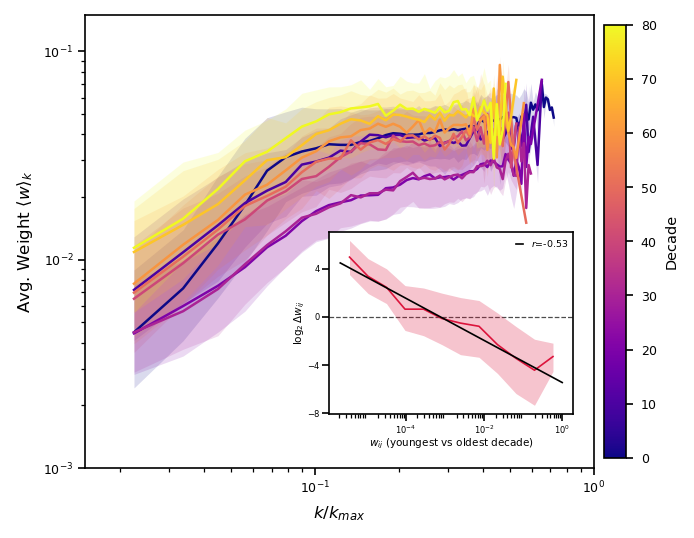

In [ ]:
from collections import defaultdict
from scipy.stats import linregress
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt

K_MAX = 89.0

def get_wk_stats(sub_dec):
    wk_dec = defaultdict(list)
    for _, row in sub_dec.iterrows():
        A = row.connectome.copy()
        np.fill_diagonal(A, 0)
        if A.max() > 0:
            A = A / A.max()
        k, s, Yi, kYi, wi = node_metrics(A)
        v = k > 1
        for ki_raw in np.unique(k[v].astype(int)):
            m = k == ki_raw
            ki_norm = ki_raw / K_MAX
            wk_dec[ki_norm].append(A[m][A[m] > 0].mean() if A[m].sum() > 0 else np.nan)
    ks_norm = np.array(sorted(wk_dec.keys()))
    w_med = np.array([np.nanmedian(wk_dec[ki]) for ki in ks_norm])
    w_p25 = np.array([np.nanpercentile(wk_dec[ki], 25) for ki in ks_norm])
    w_p75 = np.array([np.nanpercentile(wk_dec[ki], 75) for ki in ks_norm])
    return ks_norm, w_med, w_p25, w_p75

cmap_wk = plt.cm.plasma
all_decades = sorted(data['decade'].unique())
# Filtramos décadas con suficientes sujetos
valid_decades = [d for d in all_decades if len(data[data.decade == d]) >= MIN_N and d <= 80]

norm_wk = mcolors.Normalize(vmin=min(valid_decades), vmax=max(valid_decades))
sm_wk = cm.ScalarMappable(cmap=cmap_wk, norm=norm_wk)
sm_wk.set_array([])

fig, ax = plt.subplots(figsize=(4.5, 3.5))

for dec in valid_decades:
    sub_dec = data[data.decade == dec]
    color = cmap_wk(norm_wk(dec))
    ks_norm, w_med, w_p25, w_p75 = get_wk_stats(sub_dec)
    ax.loglog(ks_norm, w_med, '-', lw=1.2, color=color)
    ax.fill_between(ks_norm, w_p25, w_p75, color=color, alpha=0.15, lw=0)

# ── Inset: log2 ratio entre primera y última década ──────────────────────────
dec_y, dec_o = valid_decades[0], valid_decades[-1]

def get_mean_matrix(decade, use_grep=False):
    mats = list(data[data.decade == decade].connectome)
    if use_grep:
        return ddw_group_rep(mats, dist_mat, hemi, N_BINS, rng_ddw)
    return np.mean(mats, axis=0)

A_y = get_mean_matrix(dec_y)
A_o = get_mean_matrix(dec_o)
global_max = max(A_y.max(), A_o.max())
A_y_n = A_y / global_max
A_o_n = A_o / global_max

iu = np.triu_indices(90, k=1)
w_y = A_y_n[iu]; w_o = A_o_n[iu]
mask_edge = (w_y > 0) & (w_o > 0)
w_y_f = w_y[mask_edge]; w_o_f = w_o[mask_edge]
log_ratio = np.log2(w_o_f / w_y_f)

axins = ax.inset_axes([0.48, 0.12, 0.48, 0.40])
num_bins = 12
bins = np.logspace(np.log10(w_y_f.min()), np.log10(w_y_f.max()), num=num_bins + 1)
bin_centers = np.sqrt(bins[:-1] * bins[1:])
meds, p25s, p75s = [], [], []
for i in range(num_bins):
    mask_bin = (w_y_f >= bins[i]) & (w_y_f < bins[i + 1])
    if np.sum(mask_bin) > 5:
        vals = log_ratio[mask_bin]
        meds.append(np.median(vals)); p25s.append(np.percentile(vals, 25)); p75s.append(np.percentile(vals, 75))
    else:
        meds.append(np.nan); p25s.append(np.nan); p75s.append(np.nan)

axins.plot(bin_centers, meds, color='crimson', lw=0.8, zorder=3)
axins.fill_between(bin_centers, p25s, p75s, color='crimson', alpha=0.25, lw=0, zorder=2)
axins.axhline(0, color='k', linestyle='--', alpha=0.7, lw=0.6, zorder=1)

mask_reg = np.isfinite(np.log10(w_y_f)) & np.isfinite(log_ratio)
slope, intercept, r_value, _, _ = linregress(np.log10(w_y_f[mask_reg]), log_ratio[mask_reg])
x_vals = np.linspace(np.log10(w_y_f.min()), np.log10(w_y_f.max()), 100)
axins.plot(10 ** x_vals, intercept + slope * x_vals, color='black', lw=0.8,
           label=f'$r$={r_value:.2f}', zorder=4)
axins.set_xscale('log')
axins.set_xlabel(r'$w_{ij}$ (youngest vs oldest decade)', fontsize=5, labelpad=0.5)
axins.set_ylabel(r'$\log_2 \Delta w_{ij}$', fontsize=5, labelpad=0.5)
axins.tick_params(axis='both', which='major', labelsize=4, pad=1)
axins.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=4))
axins.yaxis.set_major_locator(ticker.MaxNLocator(5))
axins.legend(fontsize=4.5, frameon=False, loc='upper right', handlelength=0.8, borderpad=0.1)

# ── Formato panel principal ───────────────────────────────────────────────────
ax.set_xlim([0.015, 1.0])
ax.set_ylim([1e-3, 0.15])
ax.set_xlabel(r'$k / k_{max}$', fontsize=8)
ax.set_ylabel(r'Avg. Weight $\langle w \rangle_{k}$', fontsize=8)
ax.tick_params(axis='both', which='both', labelsize=6, pad=2)

# Colorbar como leyenda continua
cbar = fig.colorbar(sm_wk, ax=ax, orientation='vertical', pad=0.02, fraction=0.04)
cbar.set_label('Decade', fontsize=7)
cbar.ax.tick_params(labelsize=6)

plt.tight_layout(pad=0.4)
plt.savefig('borradorv1/fig_wk_single_panel_decade.pdf', bbox_inches='tight', dpi=300)
plt.show()

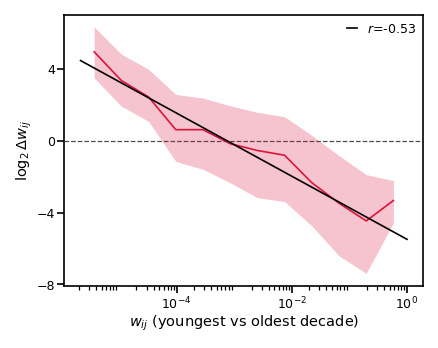

In [ ]:
from scipy.stats import linregress
import matplotlib.ticker as ticker
import numpy as np
import matplotlib.pyplot as plt

# ── Matrices medias normalizadas globalmente ──────────────────────────────────
dec_y, dec_o = valid_decades[0], valid_decades[-1]

A_y = np.mean(list(data[data.decade == dec_y].connectome), axis=0)
A_o = np.mean(list(data[data.decade == dec_o].connectome), axis=0)
global_max = max(A_y.max(), A_o.max())
A_y_n = A_y / global_max
A_o_n = A_o / global_max

iu = np.triu_indices(90, k=1)
w_y = A_y_n[iu]; w_o = A_o_n[iu]
mask_edge = (w_y > 0) & (w_o > 0)
w_y_f = w_y[mask_edge]; w_o_f = w_o[mask_edge]
log_ratio = np.log2(w_o_f / w_y_f)

# ── Bins logarítmicos (solo para visualización) ───────────────────────────────
num_bins    = 12
bins        = np.logspace(np.log10(w_y_f.min()), np.log10(w_y_f.max()), num_bins + 1)
bin_centers = np.sqrt(bins[:-1] * bins[1:])
meds, p25s, p75s = [], [], []

for i in range(num_bins):
    mask = (w_y_f >= bins[i]) & (w_y_f < bins[i + 1])
    if mask.sum() > 5:
        v = log_ratio[mask]
        meds.append(np.median(v))
        p25s.append(np.percentile(v, 25))
        p75s.append(np.percentile(v, 75))
    else:
        meds.append(np.nan); p25s.append(np.nan); p75s.append(np.nan)

meds = np.array(meds); p25s = np.array(p25s); p75s = np.array(p75s)

# ── Regresión sobre todos los puntos individuales ─────────────────────────────
mask_reg      = np.isfinite(np.log10(w_y_f)) & np.isfinite(log_ratio)
sl, ic, r, *_ = linregress(np.log10(w_y_f[mask_reg]), log_ratio[mask_reg])
x_vals        = np.linspace(np.log10(w_y_f[mask_reg].min()),
                             np.log10(w_y_f[mask_reg].max()), 100)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(2.8, 2.2))

ax.plot(bin_centers, meds, color='crimson', lw=0.8, zorder=3)
ax.fill_between(bin_centers, p25s, p75s, color='crimson', alpha=0.25, lw=0, zorder=2)
ax.axhline(0, color='k', linestyle='--', alpha=0.7, lw=0.6, zorder=1)
ax.plot(10**x_vals, ic + sl * x_vals, color='black', lw=0.8,
        label=f'$r$={r:.2f}', zorder=4)

ax.set_xscale('log')
ax.set_xlabel(r'$w_{ij}$ (youngest vs oldest decade)', fontsize=7, labelpad=1)
ax.set_ylabel(r'$\log_2 \Delta w_{ij}$', fontsize=7, labelpad=1)
ax.tick_params(axis='both', which='major', labelsize=6, pad=1)
ax.xaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=4))
ax.yaxis.set_major_locator(ticker.MaxNLocator(5))
ax.legend(fontsize=6, frameon=False, loc='upper right', handlelength=0.8, borderpad=0.1)

plt.tight_layout(pad=0.4)
plt.savefig('borradorv1/fig_wk_inset_log2ratio.pdf', bbox_inches='tight', dpi=300)
plt.show()

Tiene los greps en los paneles de abajo para que se vea pero no los vamos a usar ya que hay muchos menos puntos. 


# Age trajectory analysis. 
 

NameError: name 'valid_ds' is not defined

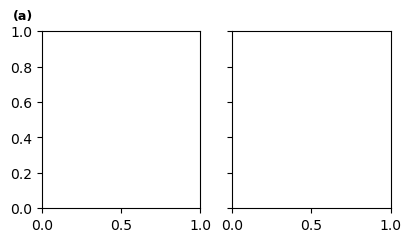

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(4.5, 2.3), sharex=True, sharey=True)

# --- Panel 1: Media de kY por sujeto (Línea de tendencia limpia) ---
ax = axs[0]

# Etiqueta (a)
ax.text(-0.18, 1.05, '(a)', transform=ax.transAxes, fontsize=9, fontweight='bold', va='bottom')

for ds in valid_ds:
    sub = data[data.dataset == ds]
    g = sub.groupby('age')['kY_obs'].mean()
    ax.plot(g.index, g, 'o-', ms=3, color=ds2col[ds], lw=1.2, alpha=0.85)

ax.set_ylabel(r'Raw Disparity $\langle kY_{obs} \rangle$', fontsize=7, labelpad=2)

# --- INSET 1: Ratio Universal (Todos los datasets fusionados) ---
axins0 = ax.inset_axes([0.48, 0.52, 0.48, 0.45]) 

g_med = data.groupby('age')['Ratio'].median()
g_p25 = data.groupby('age')['Ratio'].quantile(0.25)
g_p75 = data.groupby('age')['Ratio'].quantile(0.75)

axins0.plot(g_med.index, g_med, '-', color='k', lw=1)
axins0.fill_between(g_med.index, g_p25, g_p75, color='k', alpha=0.2, lw=0)

axins0.set_ylabel('Ratio', fontsize=5, labelpad=1)
axins0.tick_params(labelsize=4.5, pad=1)


# --- Panel 2: kY de los Group Representatives DDW (Solo trayectorias) ---
ax = axs[1]

# Etiqueta (b)
# Usamos un X ligeramente diferente para (b) porque no tiene la etiqueta del eje Y estorbando
ax.text(-0.05, 1.05, '(b)', transform=ax.transAxes, fontsize=9, fontweight='bold', va='bottom')

for ds in valid_ds:
    sg = grep_ageds[grep_ageds.dataset == ds].sort_values('age')
    if len(sg) == 0: continue
    ax.plot(sg.age, sg.kY_obs, 'o-', ms=3, color=ds2col[ds], lw=1.2, alpha=0.85)

# --- INSET 2: Ratio de los GREP Universal ---
axins1 = ax.inset_axes([0.48, 0.52, 0.48, 0.45])

g_grep = grep_ageds.groupby('age')['Ratio'].median() 

axins1.plot(g_grep.index, g_grep, '-', color='k', lw=1)
axins1.set_ylabel('Ratio', fontsize=5, labelpad=1)
axins1.tick_params(labelsize=4.5, pad=1)


# --- Estilos generales ---
for ax in axs:
    ax.set_xlabel('Age', fontsize=7, labelpad=2)
    ax.tick_params(axis='both', which='major', labelsize=6)

# --- Leyenda unificada inferior ---
handles = [plt.Line2D([0], [0], color=ds2col[ds], lw=1.5, marker='o', ms=4, label=f'DS {ds}') for ds in valid_ds]
fig.legend(handles=handles, loc='lower center', ncol=len(valid_ds),
           fontsize=5, bbox_to_anchor=(0.5, -0.05), frameon=False)

plt.tight_layout(pad=0.5)
plt.savefig('borradorv1/fig2_age_trajectory_avgY_with_insets.pdf', bbox_inches='tight', dpi=300)
plt.show()

### Por hacer, trayectorias de grado y peso... pero no se si seguirian haciendo falta despues de la figura de pesos por edades...

Calculando métricas extra para datos crudos...
Calculando métricas extra para group representatives...


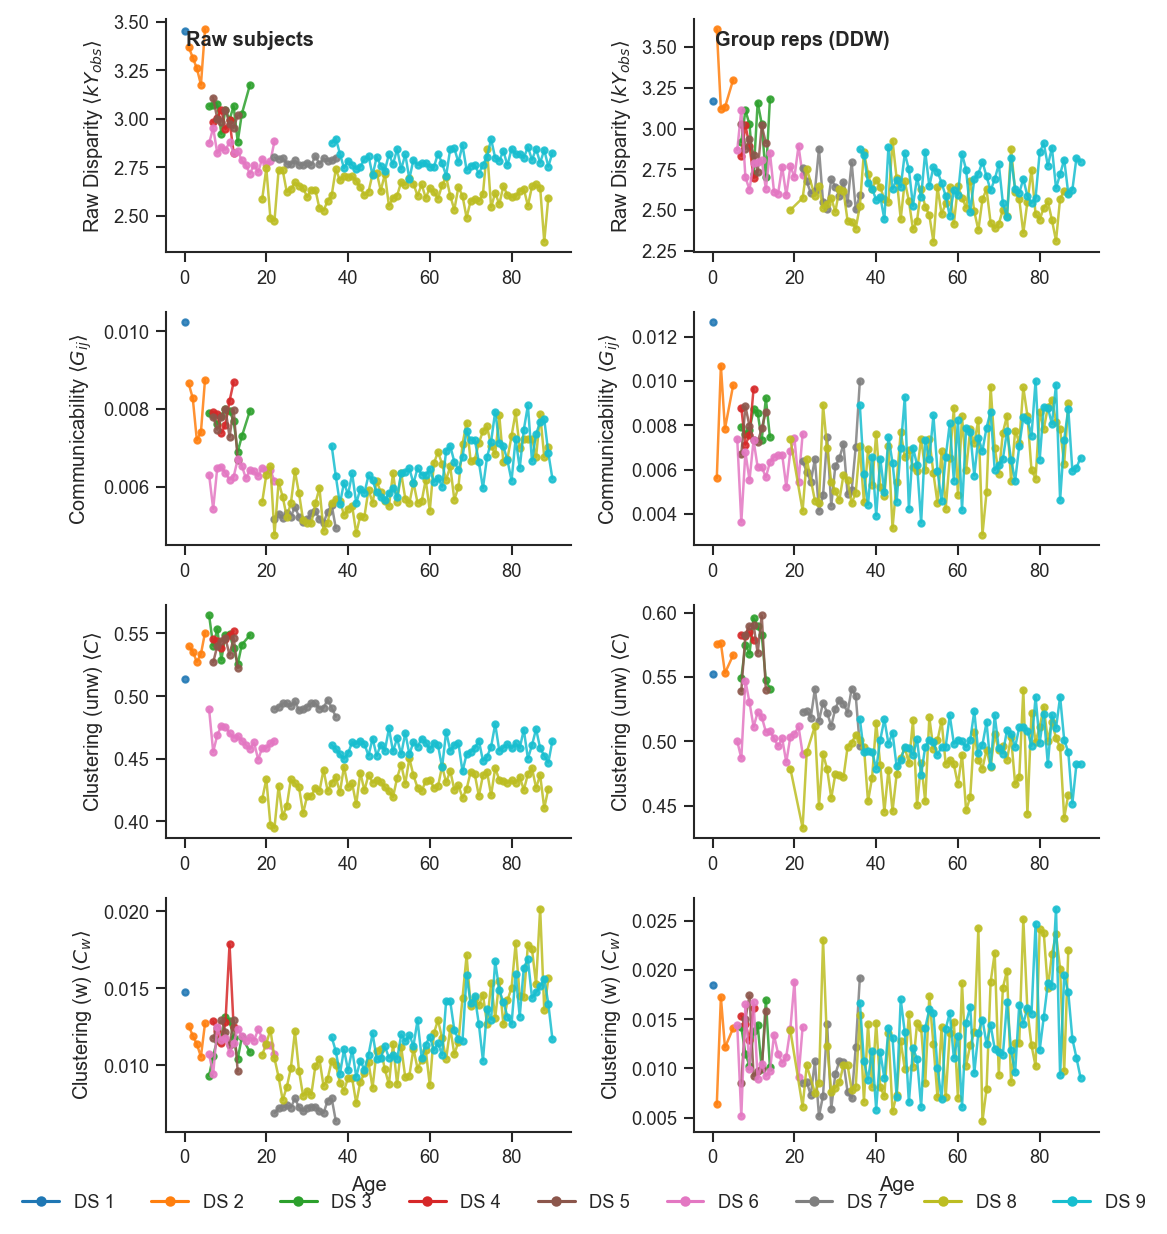

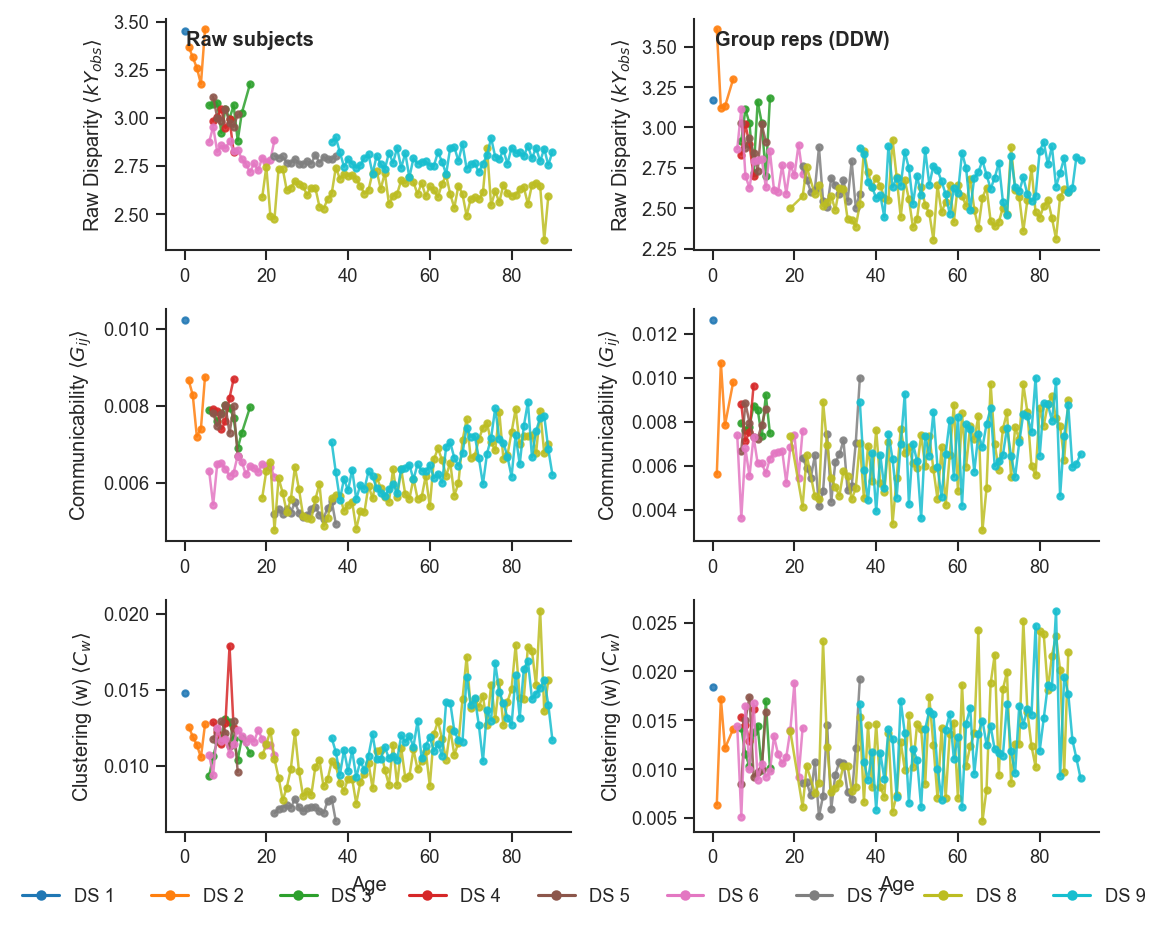

In [ ]:

from scipy.linalg import expm, eigvals
# ── Configuración global de estilo ───────────────────────────────────────────
sns.set_theme(style="ticks", context="paper")
import numpy as np
import networkx as nx
from scipy.linalg import expm, eigvals
def compute_extra_metrics(df, rho=0.99):
    """
    Añade C_unw, C_w y comm_mean.
    Aplica normalización espectral estricta para evitar overflow en expm.
    """
    c_unw_list, c_w_list, comm_list = [], [], []
    
    for _, row in df.iterrows():
        A = row.connectome.copy()
        np.fill_diagonal(A, 0)
        N = A.shape[0]
        
        # Redes para clustering
        G_unw = nx.from_numpy_array((A > 0).astype(float))
        G_w   = nx.from_numpy_array(A)
        
        c_unw_list.append(nx.average_clustering(G_unw))
        c_w_list.append(nx.average_clustering(G_w, weight='weight'))

        # Normalización espectral y comunicabilidad
        sr = np.abs(eigvals(A)).max()
        A_norm = A * (rho / sr) if sr > 0 else A
        
        try:
            C = expm(A_norm)
            comm = (C.sum() - np.trace(C)) / (N * (N - 1))
        except Exception:
            comm = np.nan
            
        comm_list.append(comm)

    df = df.copy()
    df['C_unw']     = c_unw_list
    df['C_w']       = c_w_list
    df['comm_mean'] = comm_list
    
    return df

# ── 2. Función de visualización modular ──────────────────────────────────────
def plot_trajectories(data_raw, data_grep, valid_ds, ds2col, include_cunw=True, savepath=None):
    """
    Genera la figura de trayectorias. Ajusta su tamaño dinámicamente según 
    se incluya o no el clustering no pesado (C_unw).
    """
    metrics_cfg = [
        ('kY_obs',    r'Raw Disparity $\langle kY_{obs}\rangle$'),
        ('comm_mean', r'Communicability $\langle G_{ij}\rangle$'),
    ]
    if include_cunw:
        metrics_cfg.append(('C_unw', r'Clustering (unw) $\langle C\rangle$'))
    metrics_cfg.append(('C_w', r'Clustering (w) $\langle C_w\rangle$'))

    n_rows = len(metrics_cfg)
    fig_height = 8 if include_cunw else 6
    fig, axs = plt.subplots(n_rows, 2, figsize=(7, fig_height))

    for row_i, (metric, ylabel) in enumerate(metrics_cfg):
        for col_i, df in enumerate([data_raw, data_grep]):
            ax = axs[row_i, col_i]

            for ds in valid_ds:
                sub = df[df.dataset == ds].sort_values('age')
                if len(sub) == 0 or metric not in sub.columns:
                    continue
                g = sub.groupby('age')[metric].mean()
                ax.plot(g.index, g.values, 'o-', ms=3, color=ds2col[ds], lw=1.2, alpha=0.85)

            ax.set_ylabel(ylabel)
            
            # Etiquetado interno de columnas (reemplazo sin título)
            if row_i == 0:
                col_label = 'Raw subjects' if col_i == 0 else 'Group reps (DDW)'
                ax.text(0.05, 0.95, col_label, transform=ax.transAxes, 
                        fontweight='bold', va='top', ha='left')

            if row_i == n_rows - 1:
                ax.set_xlabel('Age')

    # Aplicar estilo despine congruente
    sns.despine(fig)

    # Leyenda unificada
    handles = [plt.Line2D([0], [0], color=ds2col[ds], lw=1.5, marker='o', ms=4, label=f'DS {ds}')
               for ds in valid_ds]
    fig.legend(handles=handles, loc='lower center', ncol=len(valid_ds), 
               bbox_to_anchor=(0.5, -0.02), frameon=False)

    plt.tight_layout(pad=0.5, h_pad=1.2, w_pad=0.8)
    
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=300)
    plt.show()

# ── 3. Ejecución ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("Calculando métricas extra para datos crudos...")
    data = compute_extra_metrics(data)

    print("Calculando métricas extra para group representatives...")
    grep_ageds = compute_extra_metrics(grep_ageds)

    # Versión 1: Con clustering unweighted (4x2)
    plot_trajectories(data, grep_ageds, valid_ds, ds2col,   
                      include_cunw=True, 
                      savepath='borradorv1/fig_trajectories_4x2.pdf')

    # Versión 2: Sin clustering unweighted (3x2)
    plot_trajectories(data, grep_ageds, valid_ds, ds2col, 
                      include_cunw=False, 
                      savepath='borradorv1/fig_trajectories_3x2.pdf')

## Scatter 


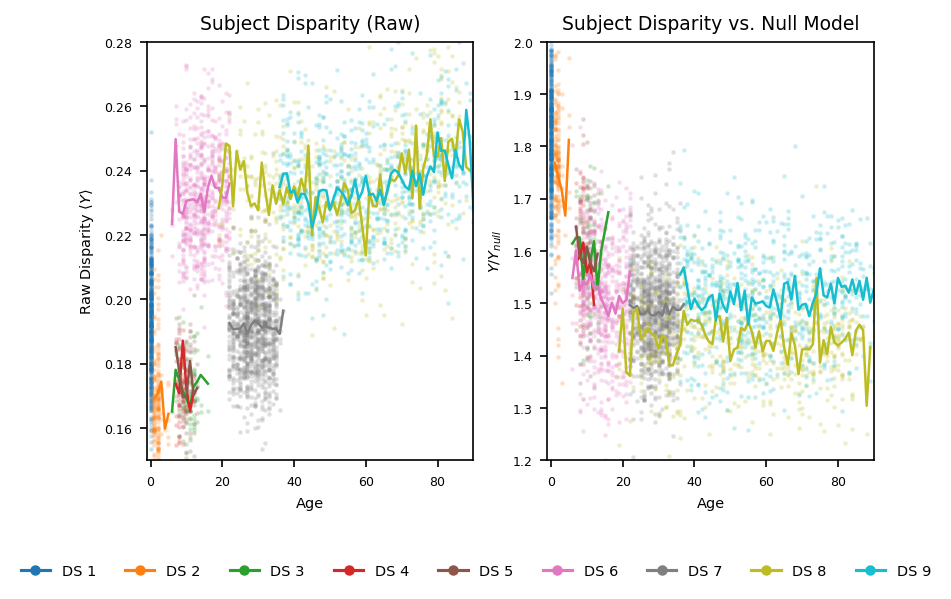

In [ ]:

# ---------------------------------------------------------
# Creación de la Figura 2
# ---------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(5.5,3.5), sharex=True)

# --- Panel 1: Scatter crudo de <kY> por sujeto ---
ax = axs[0]
for ds in valid_ds:
    # Scatter de puntos individuales (sujetos)
    sub = data[data.dataset == ds]
    ax.scatter(sub.age, sub.Y_obs, s=2, alpha=0.15, color=ds2col[ds], rasterized=True)
    
    # Línea de la media por edad
    g = sub.groupby('age')['Y_obs'].mean()
    ax.plot(g.index, g, '-', color=ds2col[ds], lw=1.2)

ax.set_ylabel(r'Raw Disparity $\langle Y \rangle$')
ax.set_title('Subject Disparity (Raw)', fontsize=9)

# --- Panel 2: Scatter normalizado (Z-score) por sujeto ---
ax = axs[1]
for ds in valid_ds:
    sub = data[data.dataset == ds]
    ax.scatter(sub.age, sub.Ratio, s=2, alpha=0.15, color=ds2col[ds], rasterized=True)
    
    g = sub.groupby('age')['Ratio'].mean()
    ax.plot(g.index, g, '-', color=ds2col[ds], lw=1.2)

# Línea base del modelo nulo (Z=0)
ax.set_ylabel(r'$Y/Y_{null}$')
ax.set_title('Subject Disparity vs. Null Model', fontsize=9)


# --- Estilos generales ---
for i in range(2):
    axs[i].set_xlabel('Age')
    axs[i].set_xlim(-1, 90)

axs[1].set_ylim(1.2,2.0)
axs[0].set_ylim(0.15,0.28)

# Leyenda unificada
handles = [plt.Line2D([0],[0], color=ds2col[ds], lw=1.5, marker='o', ms=4, label=f'DS {ds}') for ds in valid_ds]
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=len(valid_ds), fontsize=7, frameon=False)

plt.tight_layout(pad=1.0)
plt.savefig('presentation/fig2_age_trajectory_analysis.png', bbox_inches='tight')
plt.show()

# Node disparity evolution with age. Predictors.

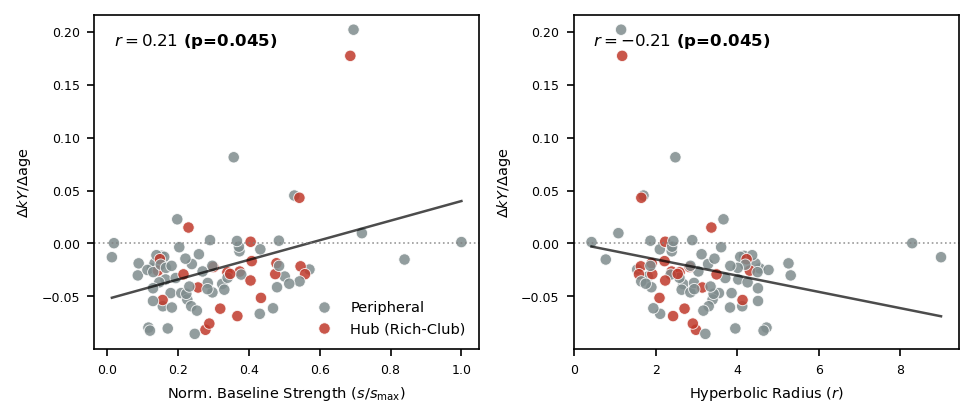

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress, spearmanr

# ── 1. Topología Baseline Determinista (Promedio Aritmético ≤ 30) ────────────
young_sub = data[data.age <= 30].copy()
matrices = np.array(list(young_sub.connectome))

# Promedio bruto para definir la jerarquía estructural sin filtrado DDW
adj_mean = np.mean(matrices, axis=0)
np.fill_diagonal(adj_mean, 0)
k_base, s_base, _, _, _ = node_metrics(adj_mean)

s_norm = s_base / s_base.max()
s_min  = s_norm[s_norm > 0].min()
R_hyp  = 2 * np.log(90)
hyp_r  = np.clip(R_hyp - 2 * np.log(np.maximum(s_norm, s_min) / s_min + 1e-9), 0, R_hyp)

# Clasificación Van den Heuvel & Sporns (k > media + 1 std)
k_thr = k_base.mean() + 0.5 * k_base.std()
hub_class = ['Hub (Rich-Club)' if k > k_thr else 'Peripheral' for k in k_base]

# ── 2. Cálculo de Trayectoria con Individuos Crudos ──────────────────────────
ages = young_sub.age.values
kY_matrix = np.zeros((len(young_sub), 90))

for idx, adj in enumerate(matrices):
    adj_c = adj.copy()
    np.fill_diagonal(adj_c, 0)
    k_i, s_i, _, kY_i, _ = node_metrics(adj_c)
    
    valid = k_i > 1
    kY_matrix[idx, :] = np.where(valid, kY_i, np.nan)

# Regresión lineal kY ~ Edad nodo a nodo
node_slopes = []
for i in range(90):
    mask = np.isfinite(kY_matrix[:, i])
    if mask.sum() > 5:
        res = linregress(ages[mask], kY_matrix[mask, i])
        node_slopes.append(res.slope)
    else:
        node_slopes.append(np.nan)

df_nodes = pd.DataFrame({
    'Node': range(90),
    'Slope': node_slopes,
    'Strength': s_norm,
    'Radius': hyp_r,
    'Class': hub_class
}).dropna()

# ── 3. Visualización (1x2) ───────────────────────────────────────────────────
PALETTE = {'Hub (Rich-Club)': '#c0392b', 'Peripheral': '#7f8c8d'}
PREDICTORS = [('Strength', r'Norm. Baseline Strength ($s/s_{\max}$)'),
              ('Radius', r'Hyperbolic Radius ($r$)')]

fig, axs = plt.subplots(1, 2, figsize=(6.5, 2.8))

for ax, (col, xlabel) in zip(axs, PREDICTORS):
    sns.scatterplot(data=df_nodes, x=col, y='Slope', hue='Class', 
                    palette=PALETTE, s=30, alpha=0.85, edgecolor='w', ax=ax)
    
    r_stat, p_stat = spearmanr(df_nodes[col], df_nodes['Slope'])
    res_lin = linregress(df_nodes[col], df_nodes['Slope'])
    
    x_range = np.array([df_nodes[col].min(), df_nodes[col].max()])
    ax.plot(x_range, res_lin.intercept + res_lin.slope * x_range, 'k-', lw=1.2, alpha=0.7)
    
    ax.axhline(0, color='grey', lw=0.8, ls=':', alpha=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r'$\Delta kY / \Delta \text{age}$')
    
    p_str = f'p={p_stat:.3f}' if p_stat >= 0.001 else f'p={p_stat:.2e}'
    ax.text(0.05, 0.95, f'$r={r_stat:.2f}$ ({p_str})', transform=ax.transAxes, 
            fontsize=8, fontweight='bold', va='top')
    
    if ax == axs[0]:
        ax.legend(fontsize=7, frameon=False)
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

plt.tight_layout()
plt.savefig('borradorv1/fig_developmental_trajectories_raw.pdf', bbox_inches='tight')
plt.show()

# Embedding

## Utils

In [ ]:
import statsmodels.api as sm


def calculate_eta(adj):
    """
    Calculates the strength-degree scaling exponent (eta).
    s(k) ~ k^eta  --> log(s) = eta * log(k) + C
    """
    A = adj.copy()
    np.fill_diagonal(A, 0)
    
    s = A.sum(axis=1)                      
    k = (A > 0).sum(axis=1).astype(float)  
    
    # Filter valid nodes
    valid = k > 0
    k_valid = k[valid]
    s_valid = s[valid]
    
    if len(k_valid) == 0: return np.nan
    
    # Group by degree and calculate mean strength
    ku = np.unique(k_valid)
    s_mean = np.array([np.mean(s_valid[k_valid == ki]) for ki in ku])
    
    # Linear regression in log-log space
    slope, _, _, _, _ = linregress(np.log(ku), np.log(s_mean))
    return slope

def calculate_tau(adj, coord_file):
    """
    Calculates the weight-geometry coupling (tau) using multiple linear regression.
    log(w_ij) = C + (eta + tau - 1)*log(ki*kj) - tau*log(d_ij)
    """
    if not os.path.exists(coord_file):
        return np.nan
        
    N_total = adj.shape[0]
    A = adj.copy()
    np.fill_diagonal(A, 0)
    
    # Read Mercator coordinates ignoring comment lines
    # Columns expected: Vertex, Inf.Kappa, Inf.Theta, Inf.Hyp.Rad.
    coords = pd.read_csv(coord_file, sep='\s+', comment='#', header=None, 
                         names=['Vertex', 'Kappa', 'Theta', 'Radius'])
    
    # Create dictionaries mapping Node ID to its inferred parameters
    kappa_map = dict(zip(coords['Vertex'].astype(int), coords['Kappa']))
    theta_map = dict(zip(coords['Vertex'].astype(int), coords['Theta']))
    
    rows, cols = np.where(np.triu(A, k=1) > 0)
    
    log_w, log_k_prod, log_d = [], [], []
    
    for i, j in zip(rows, cols):
        # Only process if both nodes have inferred coordinates
        if i in kappa_map and j in kappa_map:
            w_ij = A[i, j]
            k_i, k_j = kappa_map[i], kappa_map[j]
            th_i, th_j = theta_map[i], theta_map[j]
            
            # Shortest angular distance on a circle
            delta_theta = np.pi - np.abs(np.pi - np.abs(th_i - th_j))
            
            # Similarity distance
            d_ij = (N_total / (2 * np.pi)) * delta_theta
            d_ij = max(d_ij, 1e-5) # Prevent log(0)
                
            log_w.append(np.log(w_ij))
            log_k_prod.append(np.log(k_i * k_j))
            log_d.append(np.log(d_ij))
            
    if len(log_w) == 0: return np.nan
            
    # Multiple Linear Regression
    X = pd.DataFrame({'log_k_prod': log_k_prod, 'log_d': log_d})
    X = sm.add_constant(X)
    y = log_w
    
    model = sm.OLS(y, X).fit()
    
    # The coefficient for log_d is -tau
    tau = -model.params['log_d']
    return tau

def export_to_mercator(adj_matrix, filepath):
    """
    Simetriza (undirected), binariza (unweighted) y exporta 
    la matriz a un edge list compatible con Mercator.
    """
    # Simetrizar: si hay conexión en cualquier dirección, consideramos que hay enlace
    A_sym = np.maximum(adj_matrix, adj_matrix.T)
    
    # Extraer índices del triángulo superior para evitar duplicados
    rows, cols = np.where(np.triu(A_sym, k=1) > 0)
    
    
    
    with open(filepath, 'w') as f:
        for r, c in zip(rows, cols):
            f.write(f"{r} {c}\n")
            
    return filepath

<>:44: SyntaxWarning: invalid escape sequence '\s'
<>:44: SyntaxWarning: invalid escape sequence '\s'
/var/folders/7n/71x2ltnx73b7278bb830jrf80000gn/T/ipykernel_21595/94201639.py:44: SyntaxWarning: invalid escape sequence '\s'
  coords = pd.read_csv(coord_file, sep='\s+', comment='#', header=None,


## Greps por década

In [ ]:
grep_dec = {}
decades = sorted(data.decade.unique())

for dec in decades:
    sub = data[data.decade == dec]
    if len(sub) < 3: continue # Safety: skip if not enough subjects for a consensus
        
    matrices = list(sub.connectome)
    gr = ddw_group_rep(matrices, dist_mat, hemi, N_BINS, rng_ddw)
    
    # Store in dict keyed by the ACTUAL decade (e.g., 20, 30)
    grep_dec[dec] = gr 
    export_to_mercator(gr, f'../mercator/connectomes/humans/GR_decade_{dec}.txt')

for i in {1..4}; do echo "Running DS${i}..."; ./mercator -a connectomes/humans/GR_decade_${i}0.txt; done

correr validation? 

Skipping 0s: ../mercator/connectomes/humans/GR_decade_0.inf_coord not found.
Processed Decade 10s: eta = 1.693, tau = 0.088
Processed Decade 20s: eta = 1.533, tau = 0.094
Processed Decade 30s: eta = 1.439, tau = 0.118
Processed Decade 40s: eta = 1.844, tau = 0.048
Skipping 50s: ../mercator/connectomes/humans/GR_decade_50.inf_coord not found.
Skipping 60s: ../mercator/connectomes/humans/GR_decade_60.inf_coord not found.
Skipping 70s: ../mercator/connectomes/humans/GR_decade_70.inf_coord not found.
Skipping 80s: ../mercator/connectomes/humans/GR_decade_80.inf_coord not found.
Skipping 90s: ../mercator/connectomes/humans/GR_decade_90.inf_coord not found.


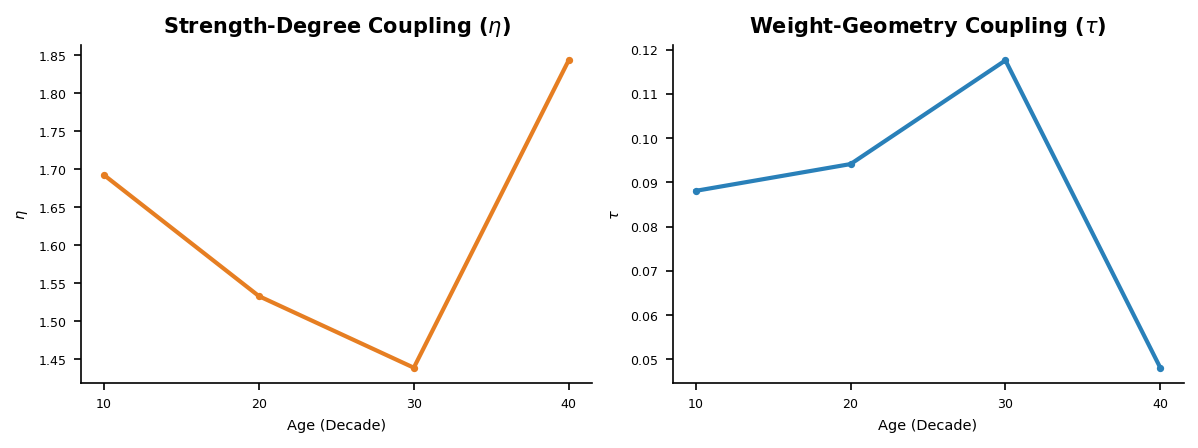

In [ ]:
from scipy.stats import linregress

# Directory where your Mercator outputs are stored
coord_dir = "../mercator/connectomes/humans" 

results = []

coord_dir = "../mercator/connectomes/humans" 

results = []

# Iterate directly over the keys of your dictionary! No more range() bugs.
for dec in sorted(grep_dec.keys()):
    coord_file = os.path.join(coord_dir, f'GR_decade_{dec}.inf_coord')
    
    if not os.path.exists(coord_file):
        print(f"Skipping {dec}s: {coord_file} not found.")
        continue
        
    adj = grep_dec[dec] # Matches perfectly
        
    # Calculate parameters
    eta_val = calculate_eta(adj)
    tau_val = calculate_tau(adj, coord_file)
        
    results.append({
        'Decade': dec,
        'eta': eta_val,
        'tau': tau_val
    })
    print(f"Processed Decade {dec}s: eta = {eta_val:.3f}, tau = {tau_val:.3f}")

df_params = pd.DataFrame(results)

# --- Visualization ---
fig, axs = plt.subplots(1, 2, figsize=(8, 3))

# Plot Eta
axs[0].plot(df_params['Decade'], df_params['eta'], 'o-', color='#e67e22', lw=2)
axs[0].set_title(r'Strength-Degree Coupling ($\eta$)', fontsize=10, fontweight='bold')
axs[0].set_xlabel('Age (Decade)')
axs[0].set_ylabel(r'$\eta$')

# Plot Tau
axs[1].plot(df_params['Decade'], df_params['tau'], 'o-', color='#2980b9', lw=2)
axs[1].set_title(r'Weight-Geometry Coupling ($\tau$)', fontsize=10, fontweight='bold')
axs[1].set_xlabel('Age (Decade)')
axs[1].set_ylabel(r'$\tau$')

for ax in axs:
    ax.set_xticks(df_params['Decade'])

plt.tight_layout()
plt.savefig('resultados_conectomica/fig_human_parameters_vs_age.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Coge un sujeto cualquiera de la década de los 20
sujeto_crudo = data[data.decade == 20].iloc[0].connectome

eta_crudo = calculate_eta(sujeto_crudo)
print(f"Eta de un humano crudo: {eta_crudo:.3f}")

Eta de un humano crudo: 1.664


In [ ]:
connectomes[0]

array([[   0,    0, 5414, ...,    0,  422,    0],
       [   0,    0,    0, ..., 1074,    0,    0],
       [5414,    0,    0, ...,    0,    0,    0],
       ...,
       [   0, 1074,    0, ...,    0,    0, 1658],
       [ 422,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ..., 1658,    0,    0]],
      shape=(90, 90), dtype=int32)